In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 12
Total threads: 96,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46365,Workers: 12
Dashboard: http://127.0.0.1:8787/status,Total threads: 96
Started: Just now,Total memory: 0.98 TiB
Comm: tcp://127.0.0.1:42691,Total threads: 8
Dashboard: http://127.0.0.1:44875/status,Memory: 83.91 GiB
Nanny: tcp://127.0.0.1:39761,


In [2]:
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import xarray as xr
import numpy as np
from mitgcm_assim.ctrls import load_controls_and_sensitivities

data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_withhold/run_ad/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

In [3]:
# Load all control variables and sensitivities into a Dataset
# This automatically loads grid information  -- when iteration=None this will load all available iterations
ds = load_controls_and_sensitivities(data_dir, grid_dir)
ds['XC'] = ds.XC.astype(float)
ds['YC'] = ds.YC.astype(float)
ds['Z'] = ds.Z.astype(float)
ds['XG'] = ds.XG.astype(float)
ds['YG'] = ds.YG.astype(float)

Loading all available iterations: [0, 1, 2, 3, 4, 5, 6]


In [4]:
# show every third iteration
nrows = len(ds.iter)//4 + 1
iters = np.arange(0,len(ds.iter),4)

# if there the number of iterations + 2 is not a multiple of 3, include the last iteration
# for example, with 12 iterations, we want to plot 0, 3, 6, 9, 11. 
# with 13 iterations, we want to plot 0, 3, 6, 9, 12
if (len(ds.iter)+3)%4 != 0:
    nrows += 1
    iters = np.append(iters, len(ds.iter)-1)

# iters = np.array([0,5,10,15,20])
# nrows = len(iters)

# always 3 columns, either 3 depth levels, or 3 records in the forcing data
ncols = 3
levels = np.array([-1.0, -100.0, -250.0])
lons = np.array([190.0, 220.0, 250.0])
records = np.array([0,5,10])

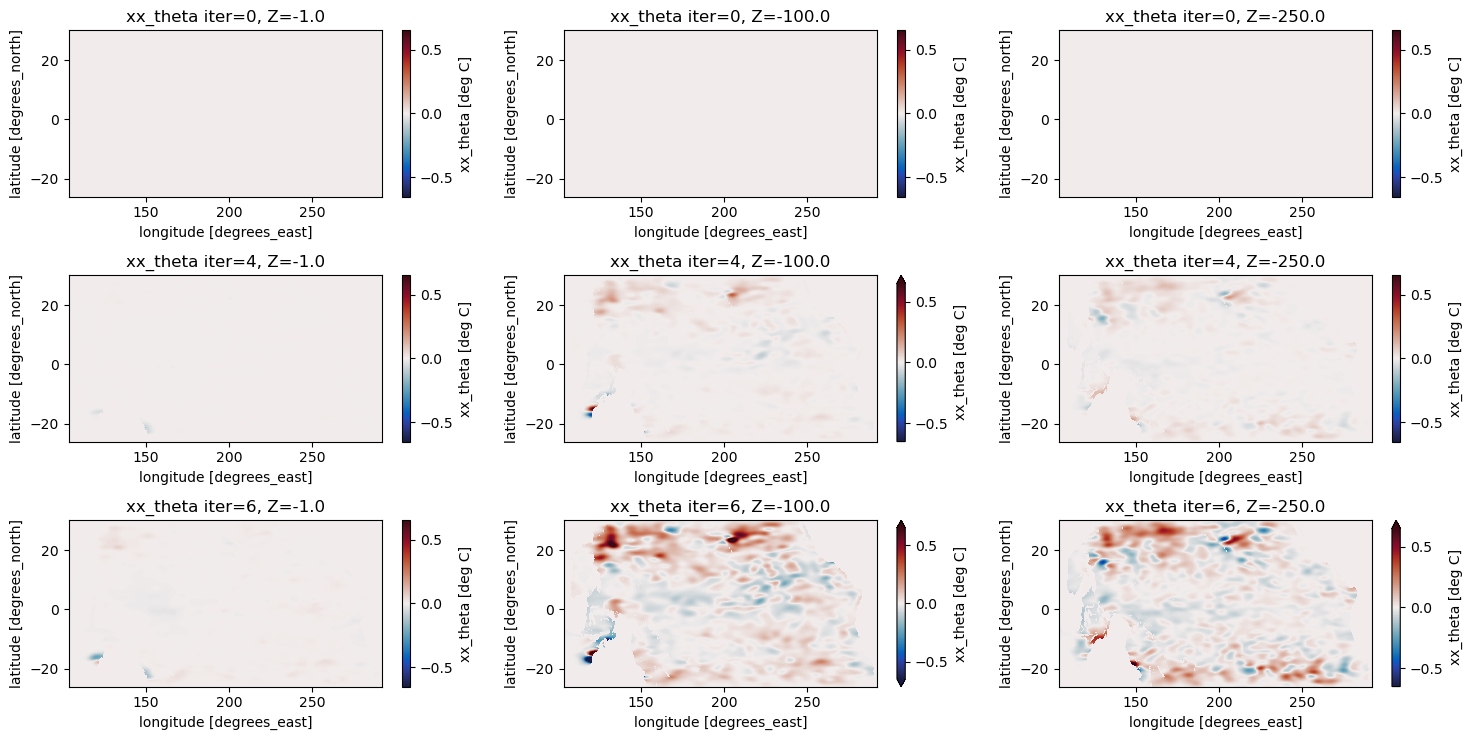

In [5]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

# iterate over rows and colunns of axes, such that each row is an iteration and each column is a depth
for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_theta'].isel(iter=iter).sel(Z=[levels[col]],method='nearest').plot(ax=axes[row,col], cmap=cmo.balance, vmin=-6.5e-1,vmax=6.5e-1)
        axes[row,col].set_title(f'xx_theta iter={ds.iter.values[iter]}, Z={levels[col]}')


plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_theta.png')

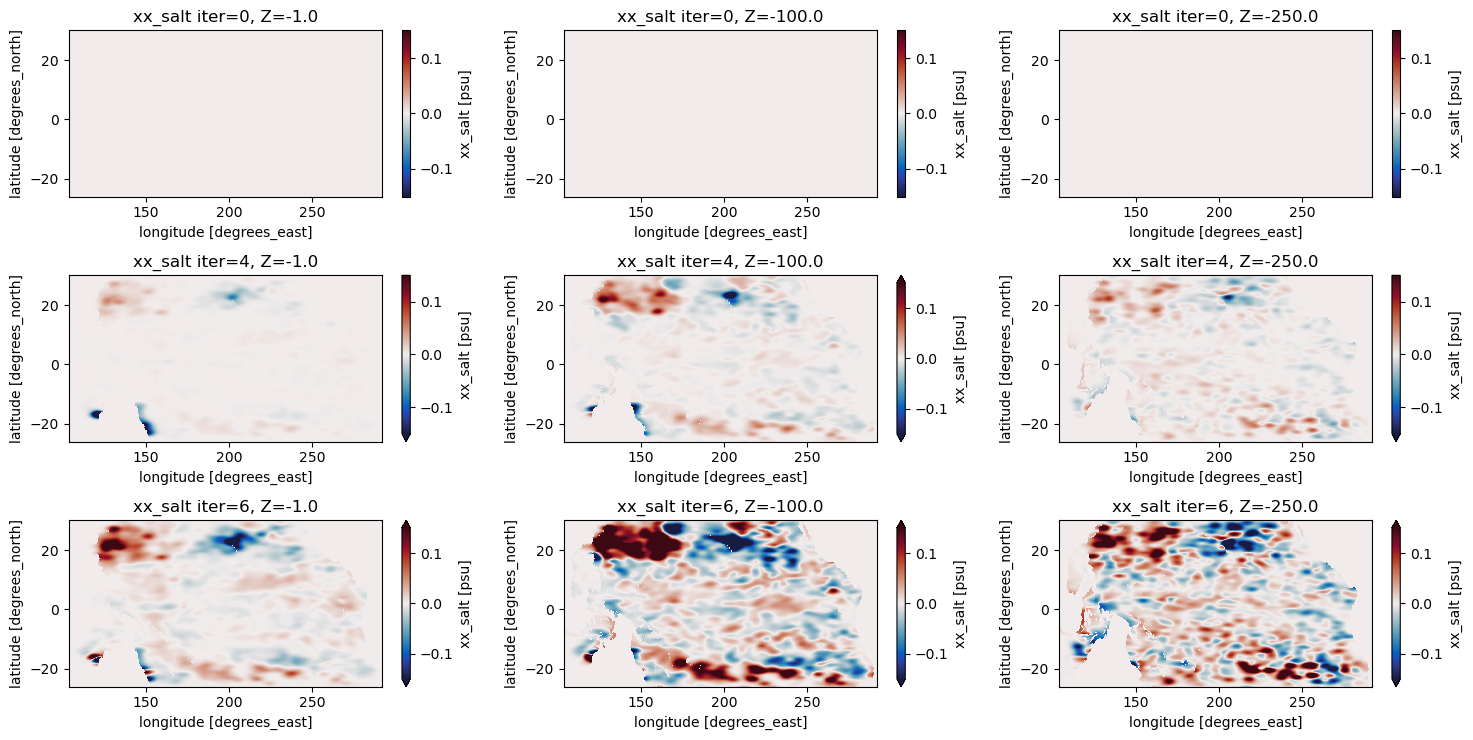

In [6]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

# iterate over rows and colunns of axes, such that each row is an iteration and each column is a depth
for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_salt'].isel(iter=iter).sel(Z=[levels[col]],method='nearest').plot(ax=axes[row,col], cmap=cmo.balance, vmin=-1.5e-1,vmax=1.5e-1)
        axes[row,col].set_title(f'xx_salt iter={ds.iter.values[iter]}, Z={levels[col]}')


plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_salt.png')

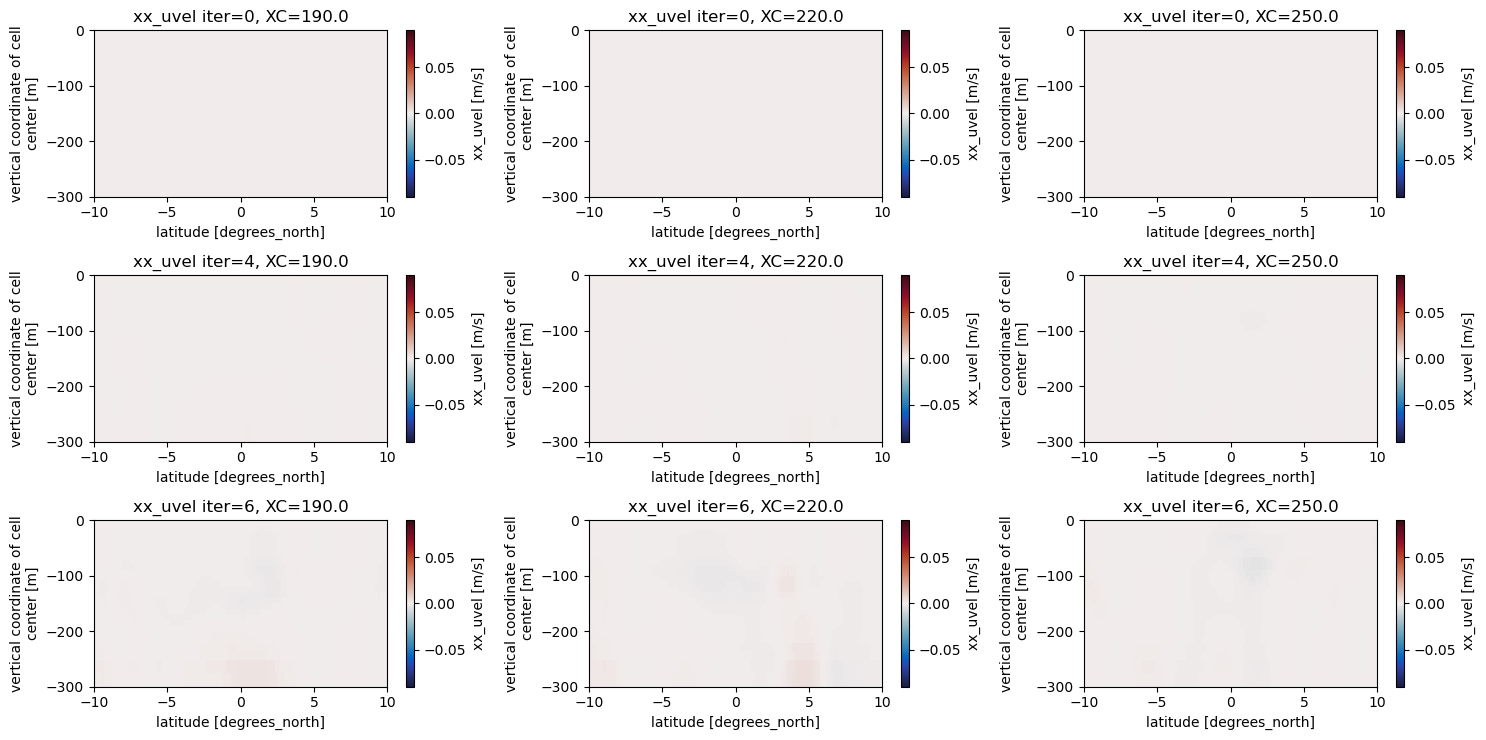

In [7]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

# iterate over rows and colunns of axes, such that each row is an iteration and each column is a longitude
for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_uvel'].isel(iter=iter).sel(Z=slice(0,-300),YC=slice(-10,10)).sel(XC=lons[col],method='nearest').plot(ax=axes[row,col], cmap=cmo.balance,  vmin=-9e-2,vmax=9e-2)
        axes[row,col].set_title(f'xx_uvel iter={ds.iter.values[iter]}, XC={lons[col]}')


plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_uvel_vertical.png')

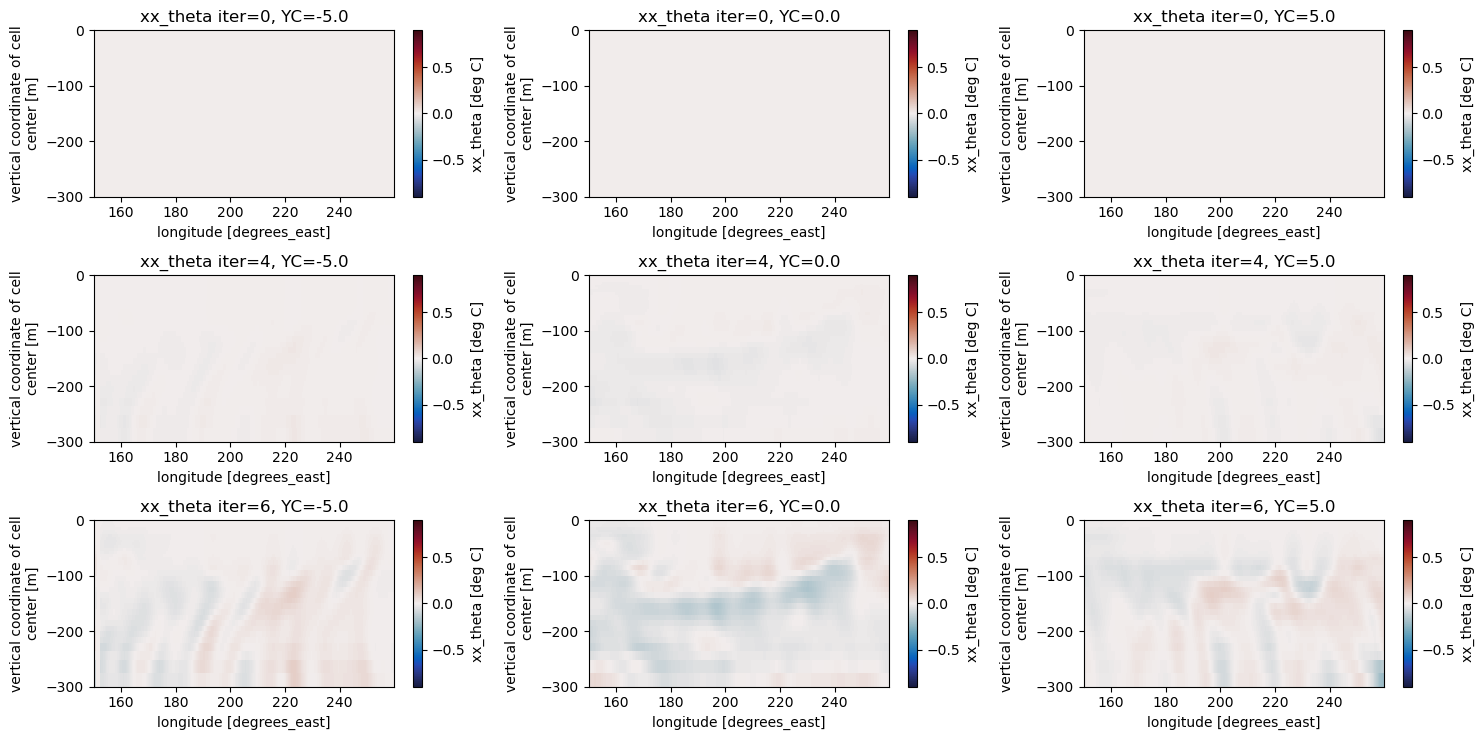

In [8]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

lats = np.array([-5.0, 0.0, 5.0])
# iterate over rows and colunns of axes, such that each row is an iteration and each column is a longitude
for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_theta'].isel(iter=iter).sel(Z=slice(0,-300),XC=slice(150,260)).sel(YC=lats[col],method='nearest').plot(ax=axes[row,col], cmap=cmo.balance,  vmin=-9e-1,vmax=9e-1)
        axes[row,col].set_title(f'xx_theta iter={ds.iter.values[iter]}, YC={lats[col]}')


plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_theta_zonal_vertical.png')

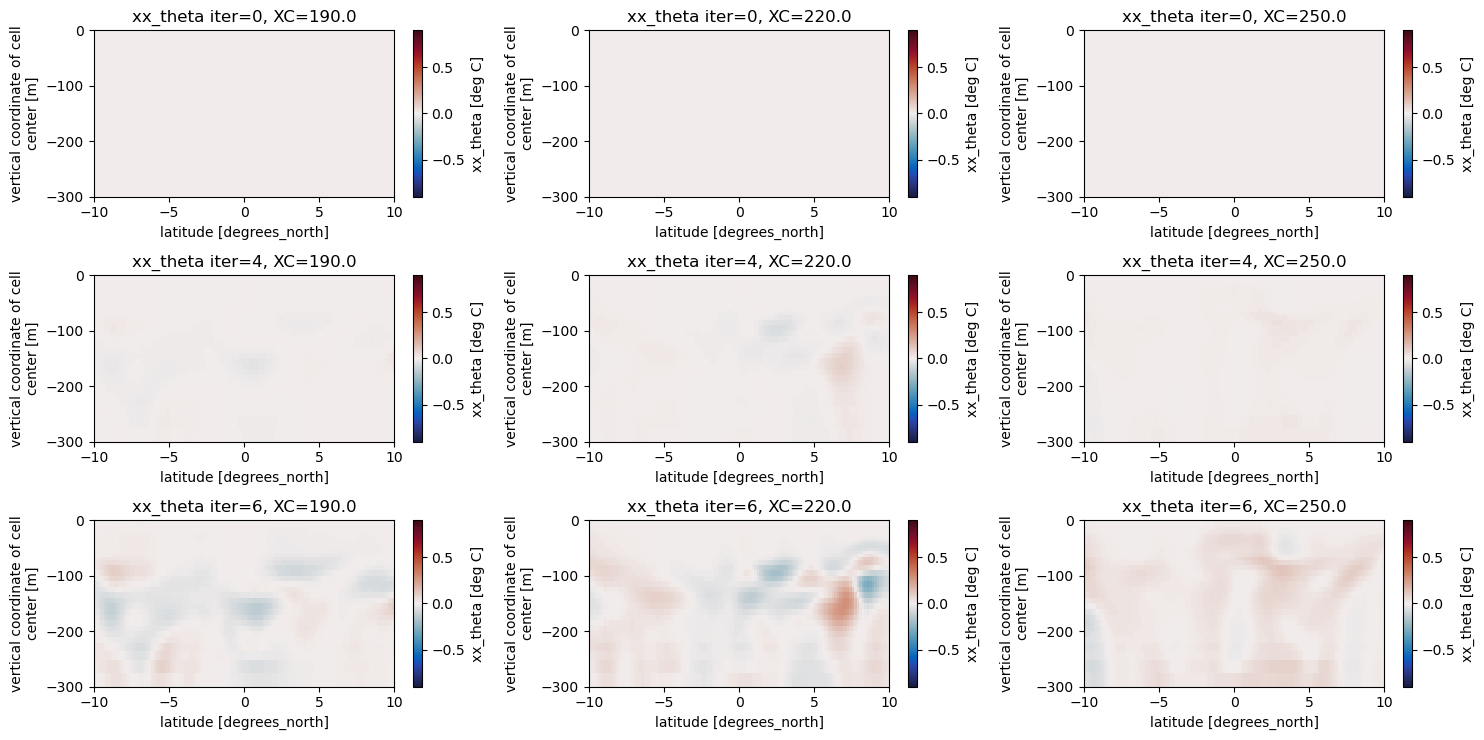

In [9]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

# iterate over rows and colunns of axes, such that each row is an iteration and each column is a longitude
for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_theta'].isel(iter=iter).sel(Z=slice(0,-300),YC=slice(-10,10)).sel(XC=lons[col],method='nearest').plot(ax=axes[row,col], cmap=cmo.balance,  vmin=-9e-1,vmax=9e-1)
        axes[row,col].set_title(f'xx_theta iter={ds.iter.values[iter]}, XC={lons[col]}')


plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_theta_meridional_vertical.png')

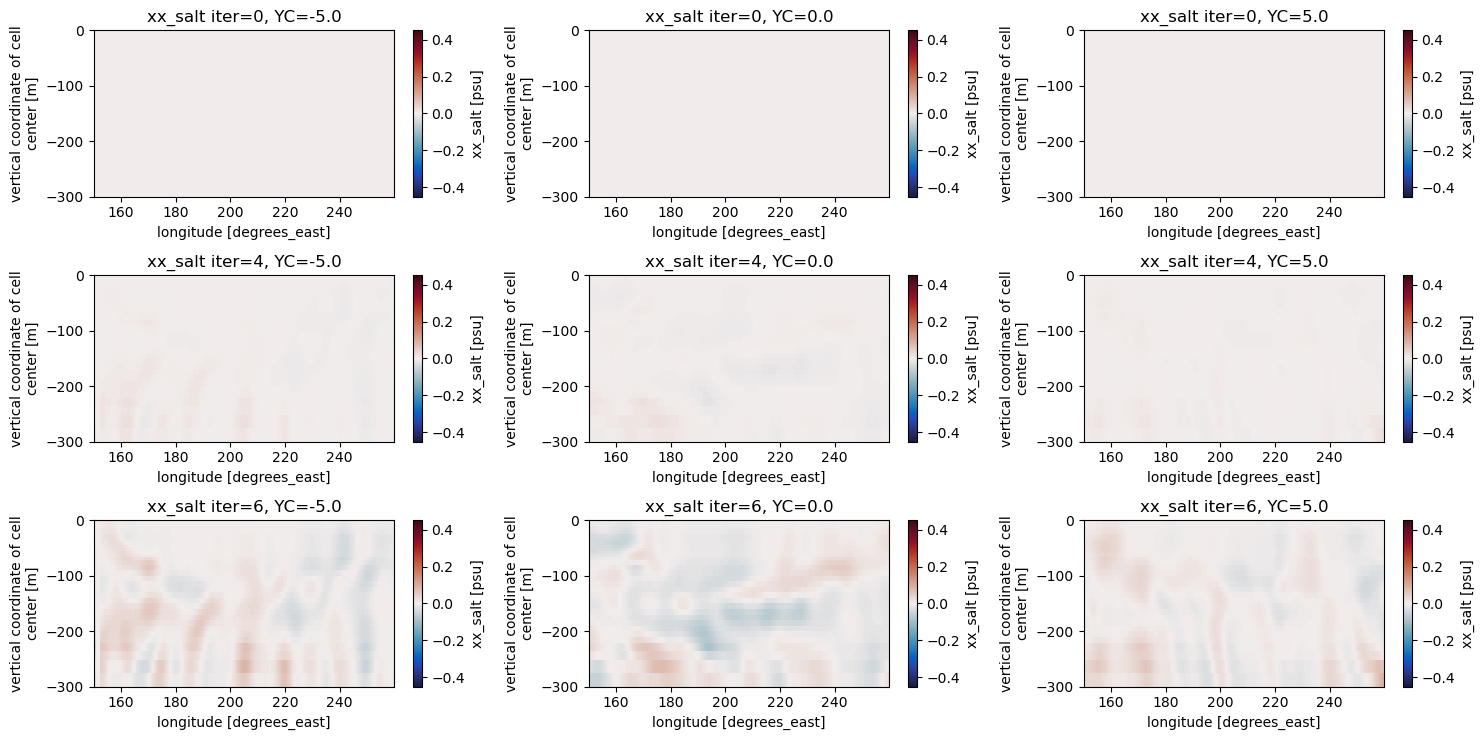

In [10]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

lats = np.array([-5.0, 0.0, 5.0])
# iterate over rows and colunns of axes, such that each row is an iteration and each column is a longitude
for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_salt'].isel(iter=iter).sel(Z=slice(0,-300),XC=slice(150,260)).sel(YC=lats[col],method='nearest').plot(ax=axes[row,col], cmap=cmo.balance,  vmin=-4.5e-1,vmax=4.5e-1)
        axes[row,col].set_title(f'xx_salt iter={ds.iter.values[iter]}, YC={lats[col]}')


plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_salt_zonal_vertical.png')

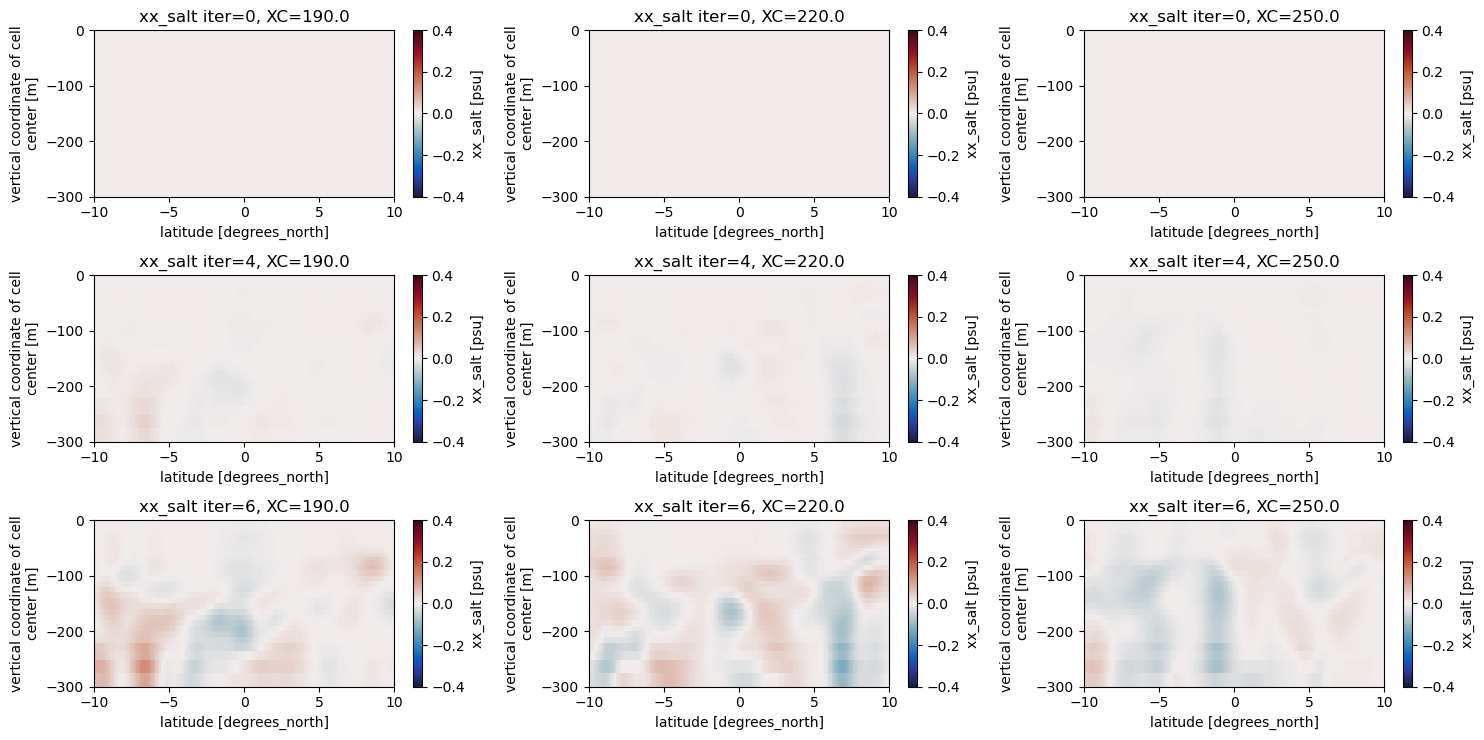

In [11]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

# iterate over rows and colunns of axes, such that each row is an iteration and each column is a longitude
for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_salt'].isel(iter=iter).sel(Z=slice(0,-300),YC=slice(-10,10)).sel(XC=lons[col],method='nearest').plot(ax=axes[row,col], cmap=cmo.balance,  vmin=-4e-1,vmax=4e-1)
        axes[row,col].set_title(f'xx_salt iter={ds.iter.values[iter]}, XC={lons[col]}')


plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_salt_meridional_vertical.png')

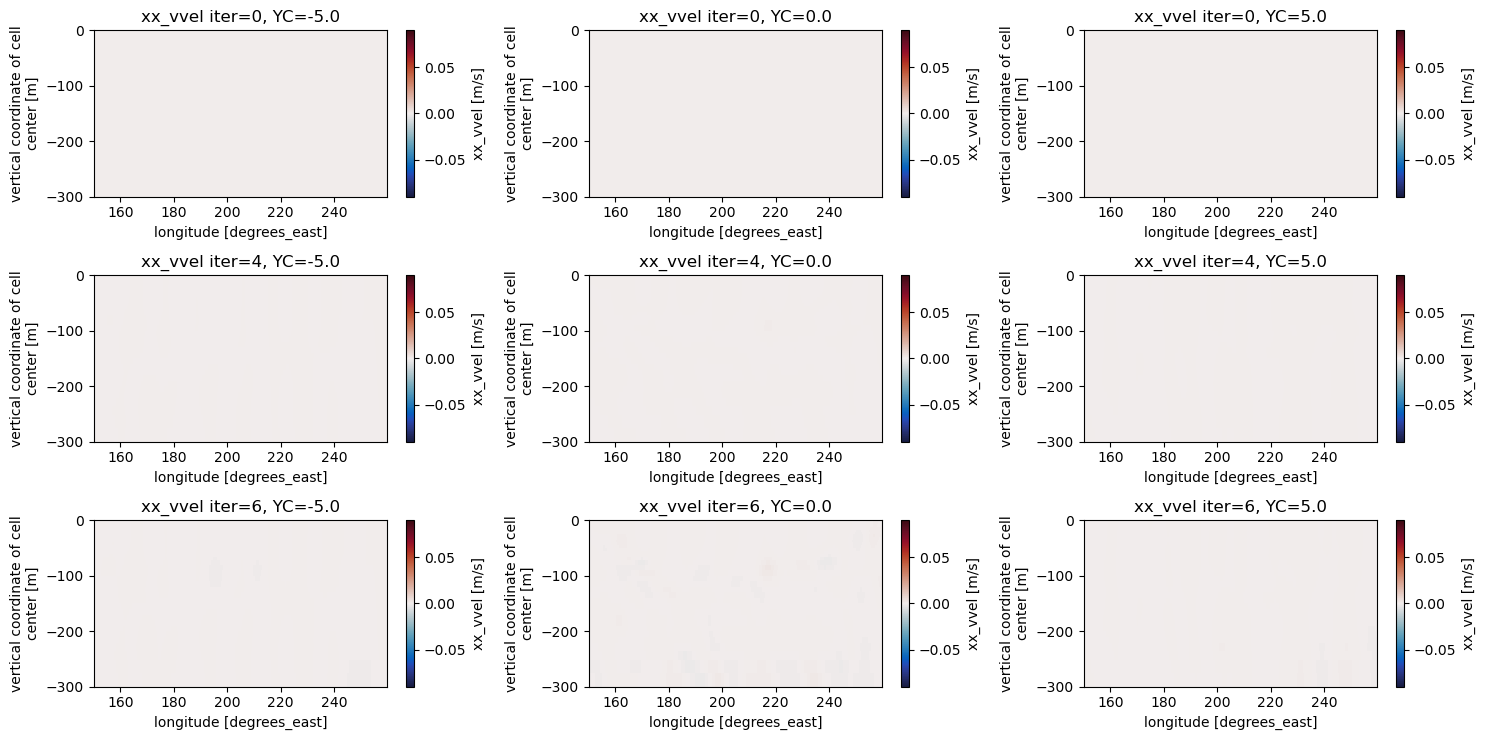

In [12]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

lats = np.array([-5.0, 0.0, 5.0])
# iterate over rows and colunns of axes, such that each row is an iteration and each column is a longitude
for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_vvel'].isel(iter=iter).sel(Z=slice(0,-300),XC=slice(150,260)).sel(YC=lats[col],method='nearest').plot(ax=axes[row,col], cmap=cmo.balance,  vmin=-9e-2,vmax=9e-2)
        axes[row,col].set_title(f'xx_vvel iter={ds.iter.values[iter]}, YC={lats[col]}')


plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_vvel_vertical.png')

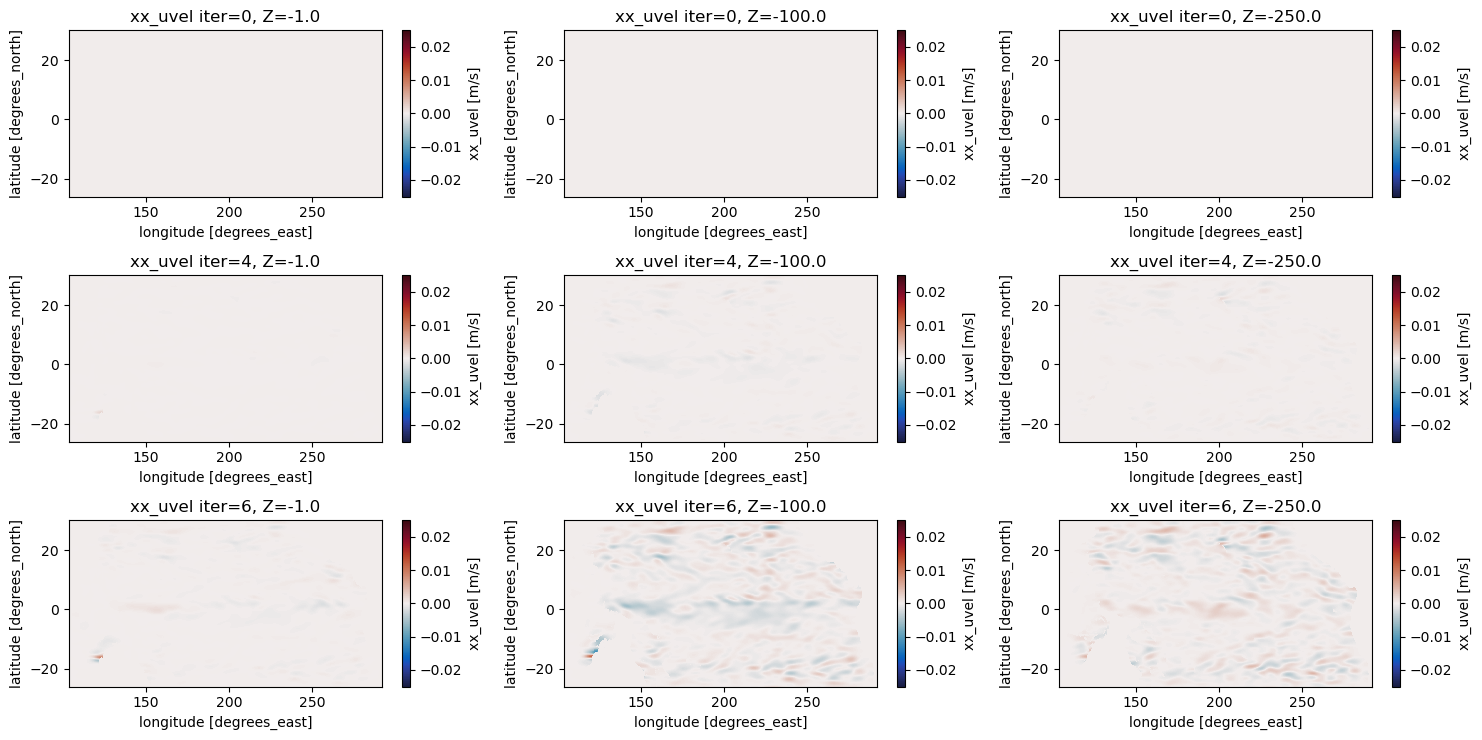

In [13]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

# iterate over rows and colunns of axes, such that each row is an iteration and each column is a depth
for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_uvel'].isel(iter=iter).sel(Z=[levels[col]],method='nearest').plot(ax=axes[row,col], cmap=cmo.balance,  vmin=-2.5e-2,vmax=2.5e-2)
        axes[row,col].set_title(f'xx_uvel iter={ds.iter.values[iter]}, Z={levels[col]}')


plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_uvel.png')

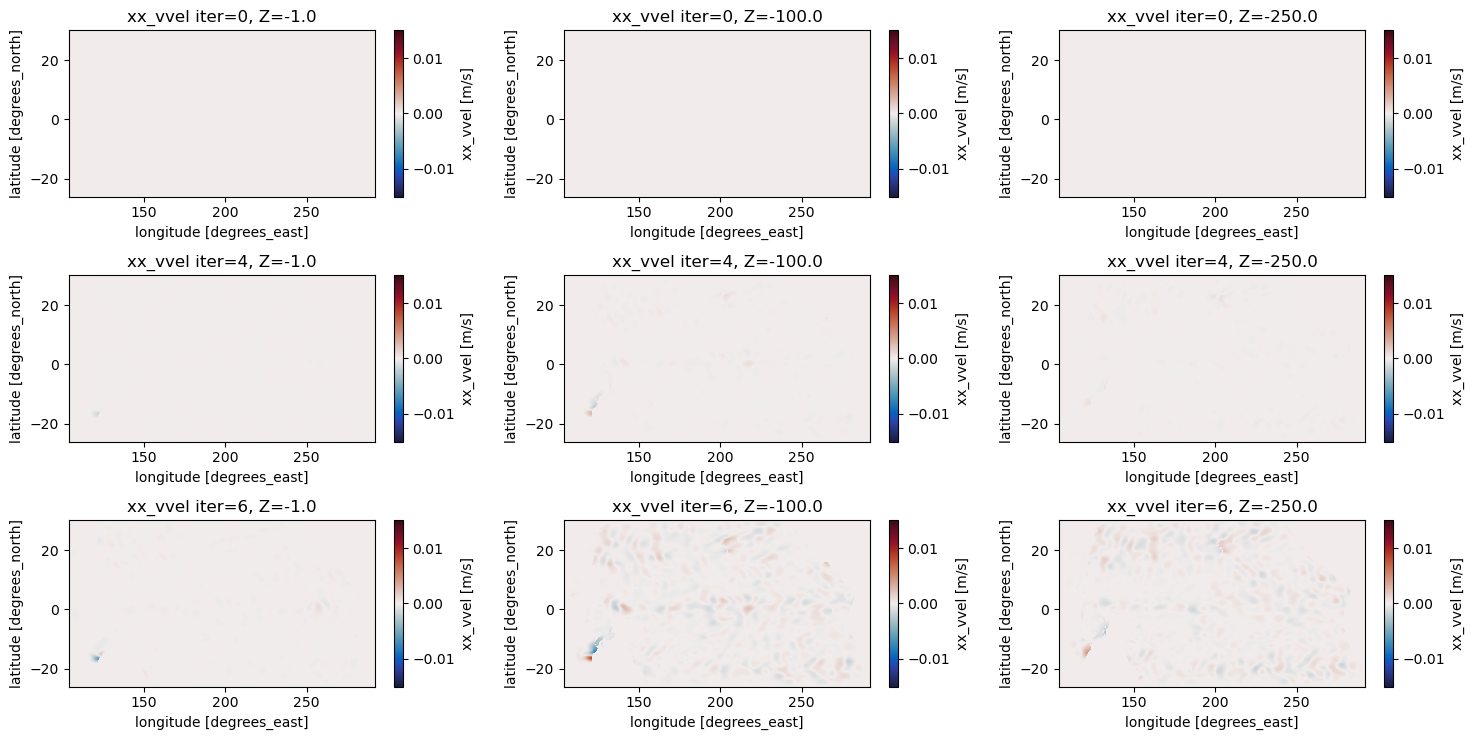

In [14]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

# iterate over rows and colunns of axes, such that each row is an iteration and each column is a depth
for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_vvel'].isel(iter=iter).sel(Z=[levels[col]],method='nearest').plot(ax=axes[row,col], cmap=cmo.balance, vmin=-1.5e-2, vmax=1.5e-2)
        axes[row,col].set_title(f'xx_vvel iter={ds.iter.values[iter]}, Z={levels[col]}')


plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_vvel.png')

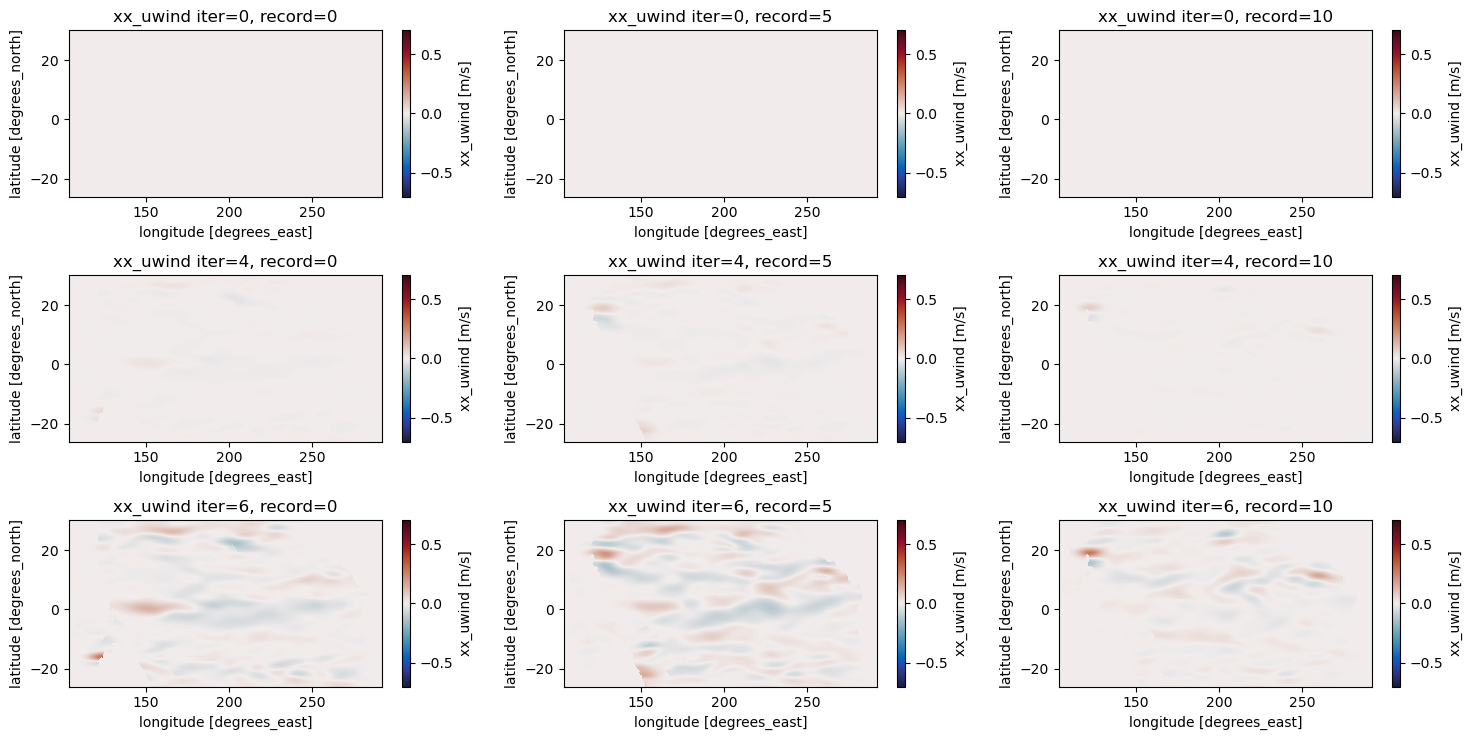

In [15]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

# iterate over rows and colunns of axes, such that each row is an iteration and each column is a depth
for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_uwind'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance, vmin=-7e-1, vmax=7e-1,)
        axes[row,col].set_title(f'xx_uwind iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_uwind.png')

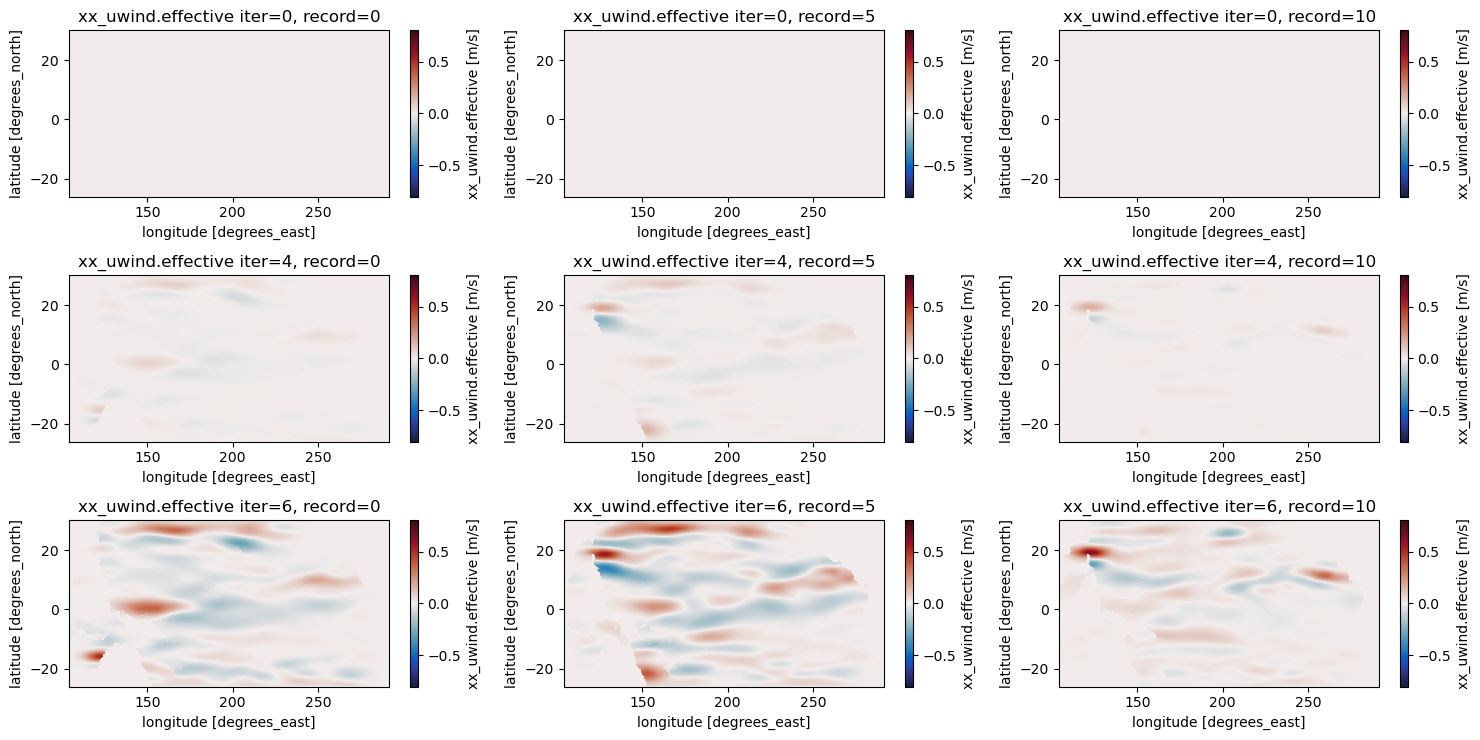

In [16]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

# iterate over rows and colunns of axes, such that each row is an iteration and each column is a depth
for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_uwind.effective'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance, vmin=-8e-1, vmax=8e-1)
        axes[row,col].set_title(f'xx_uwind.effective iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_uwind_effective.png')

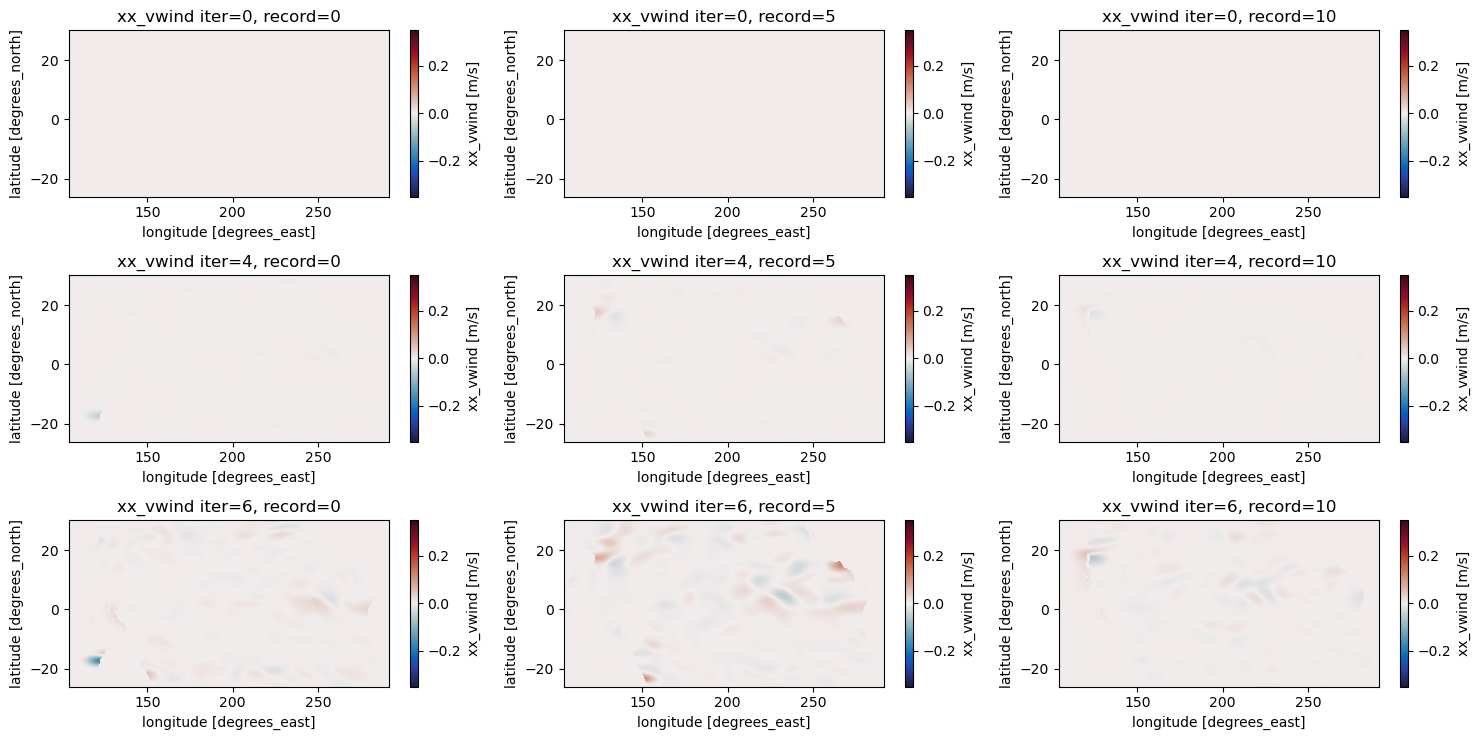

In [17]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

# iterate over rows and colunns of axes, such that each row is an iteration and each column is a depth
for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_vwind'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance, vmin=-3.5e-1, vmax=3.5e-1)
        axes[row,col].set_title(f'xx_vwind iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_vwind.png')

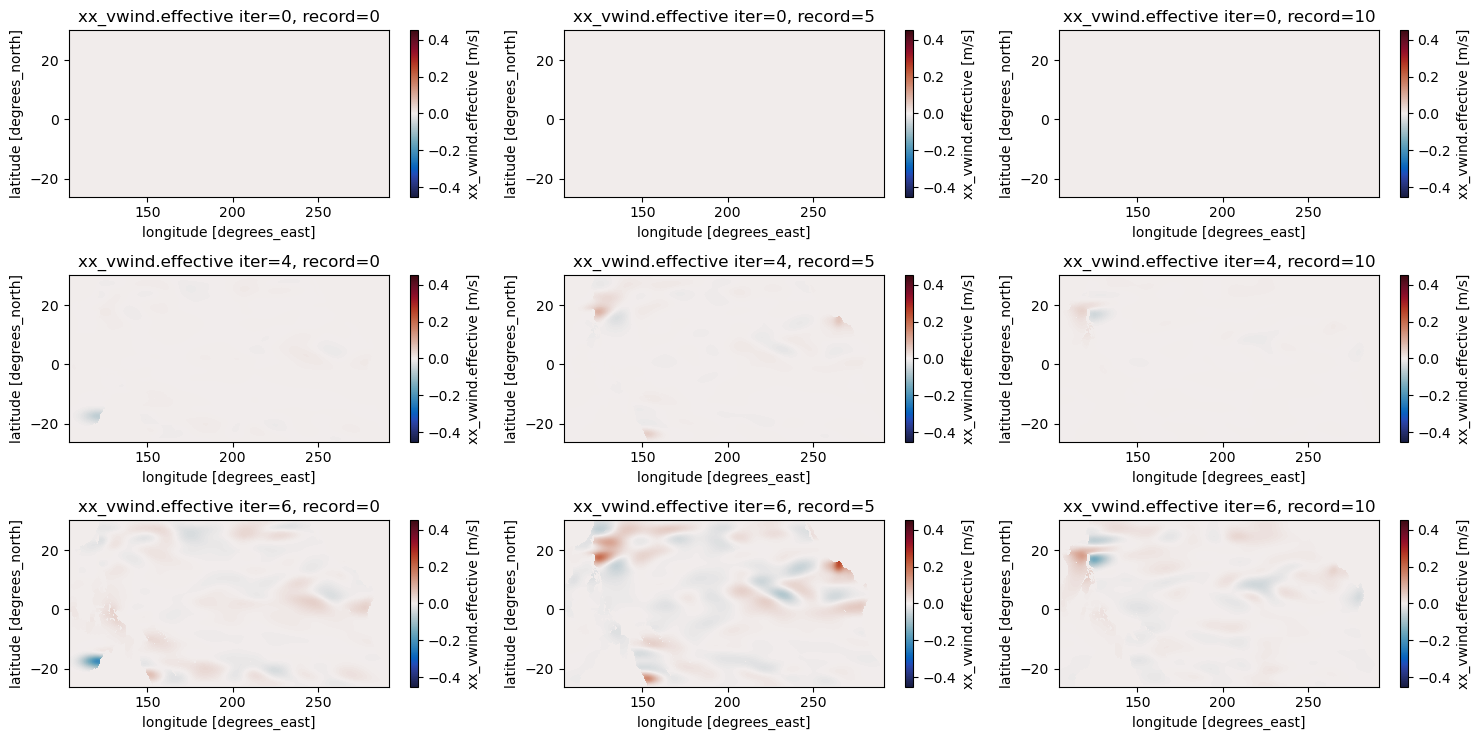

In [18]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

# iterate over rows and colunns of axes, such that each row is an iteration and each column is a depth
for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_vwind.effective'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance, vmin=-4.5e-1, vmax=4.5e-1)
        axes[row,col].set_title(f'xx_vwind.effective iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_vwind_effective.png')

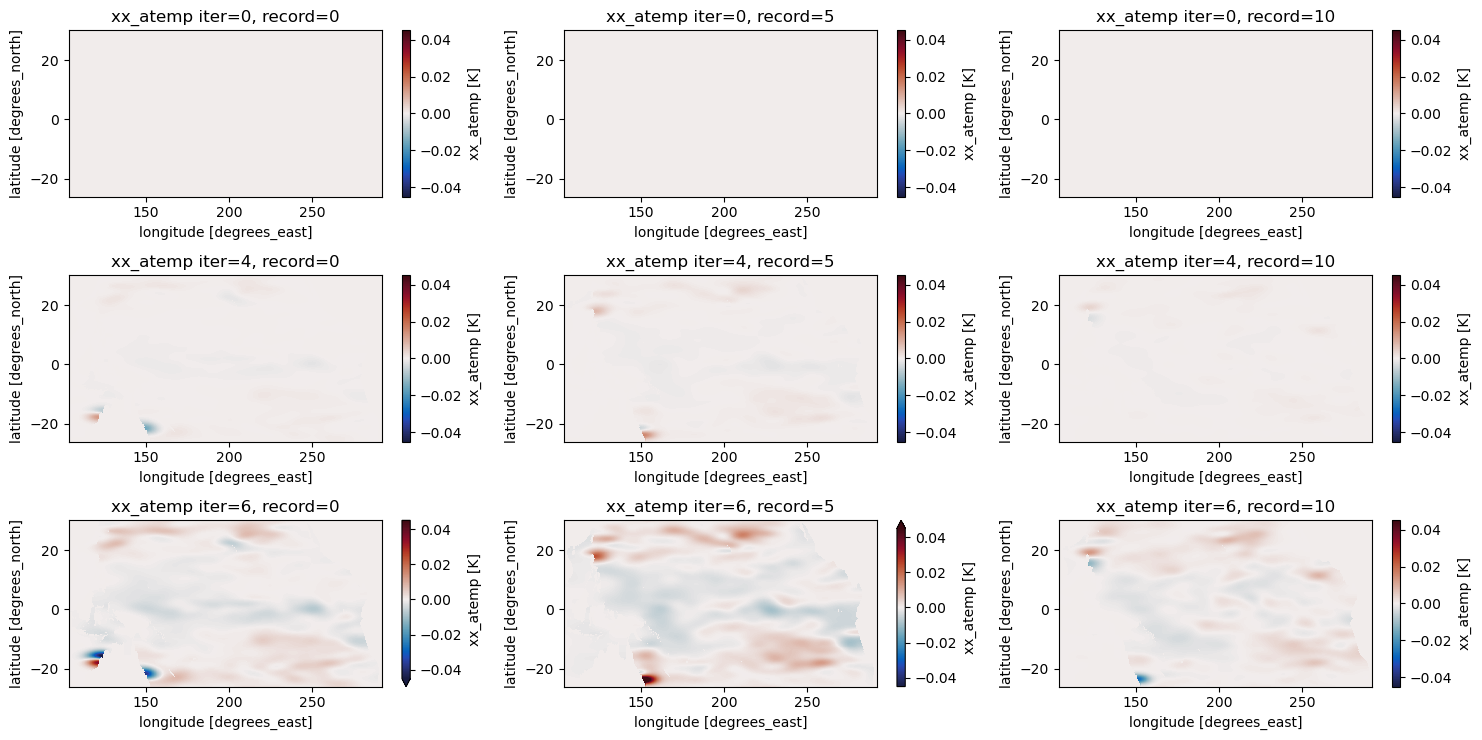

In [19]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_atemp'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance, vmin=-4.5e-2, vmax=4.5e-2)
        axes[row,col].set_title(f'xx_atemp iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_atemp.png')

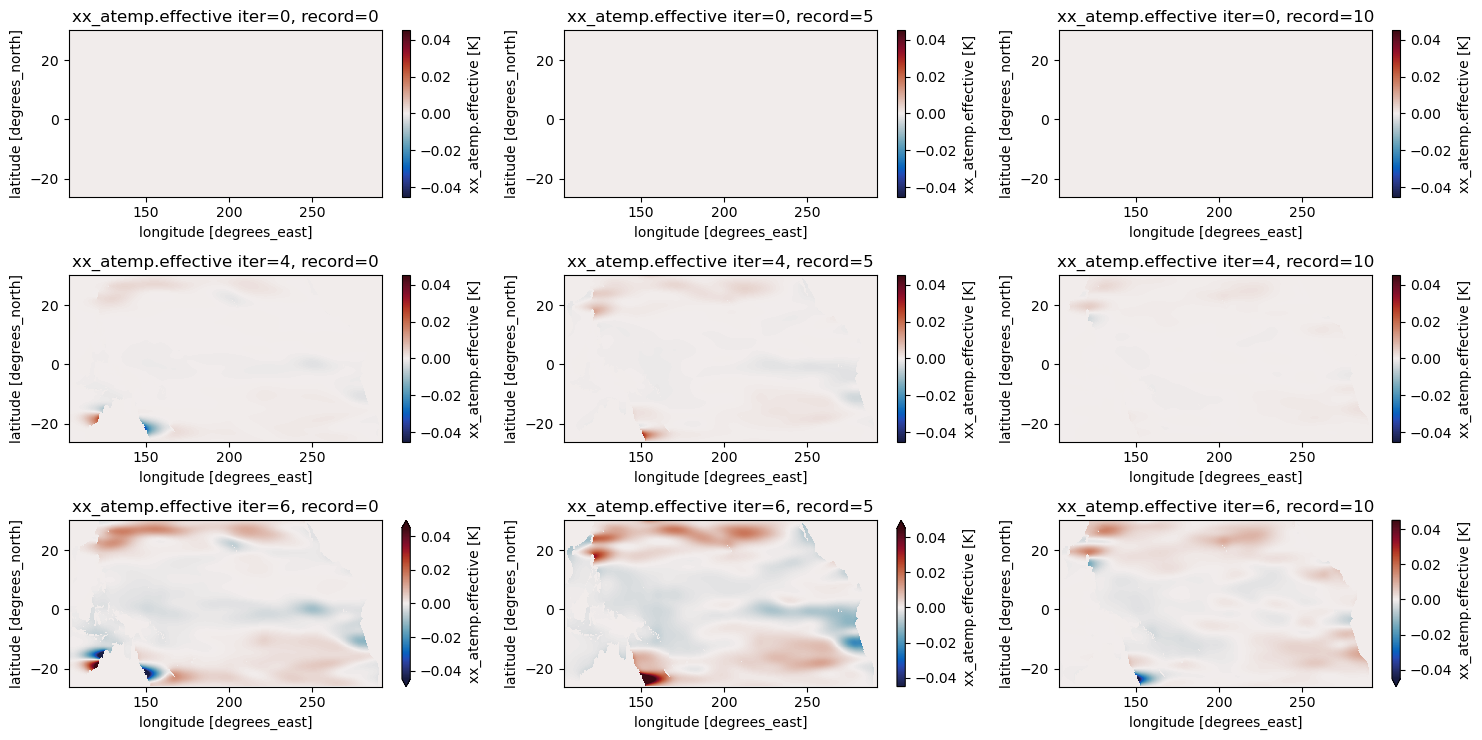

In [20]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_atemp.effective'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance, vmin=-4.5e-2, vmax=4.5e-2)
        axes[row,col].set_title(f'xx_atemp.effective iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_atemp_effective.png')

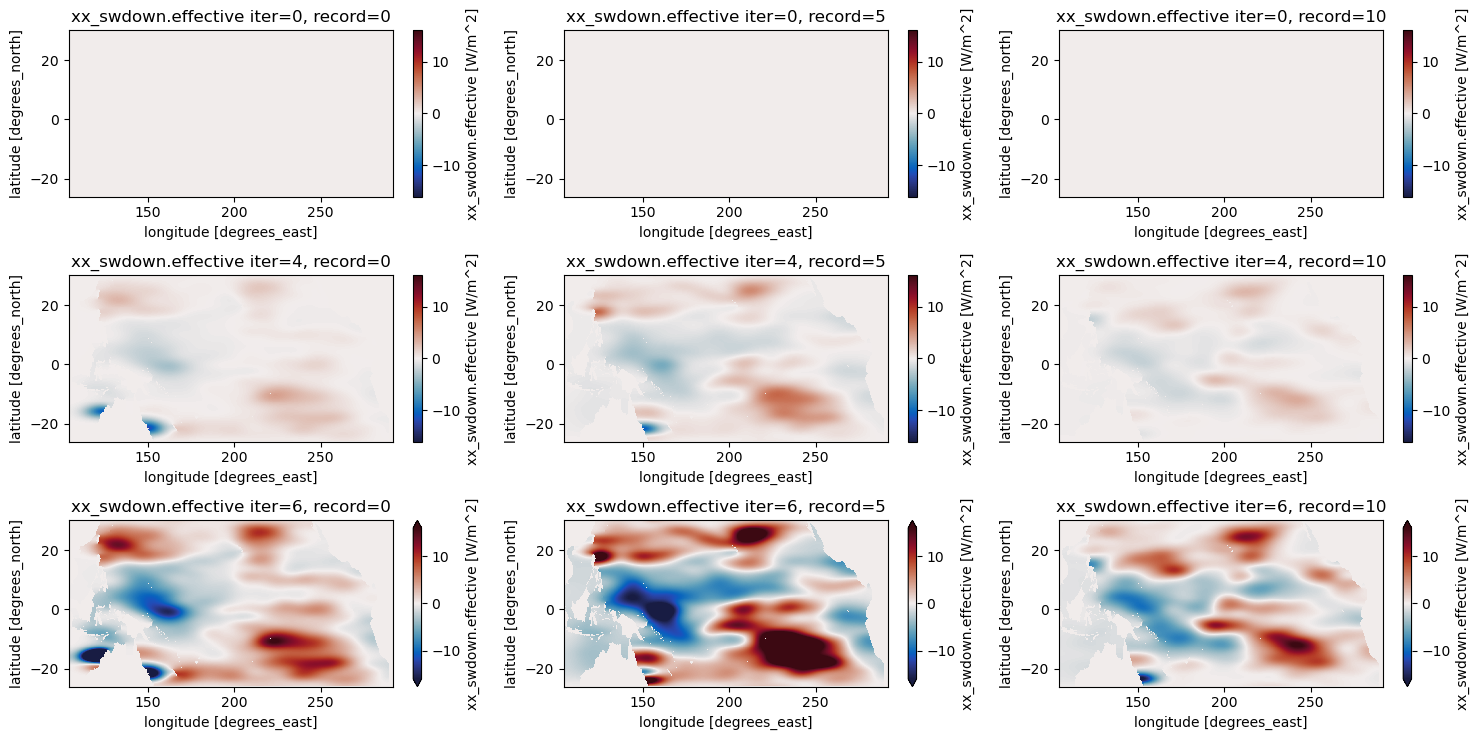

In [21]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_swdown.effective'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance, vmin=-16, vmax=16)
        axes[row,col].set_title(f'xx_swdown.effective iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_swdown_effective.png')

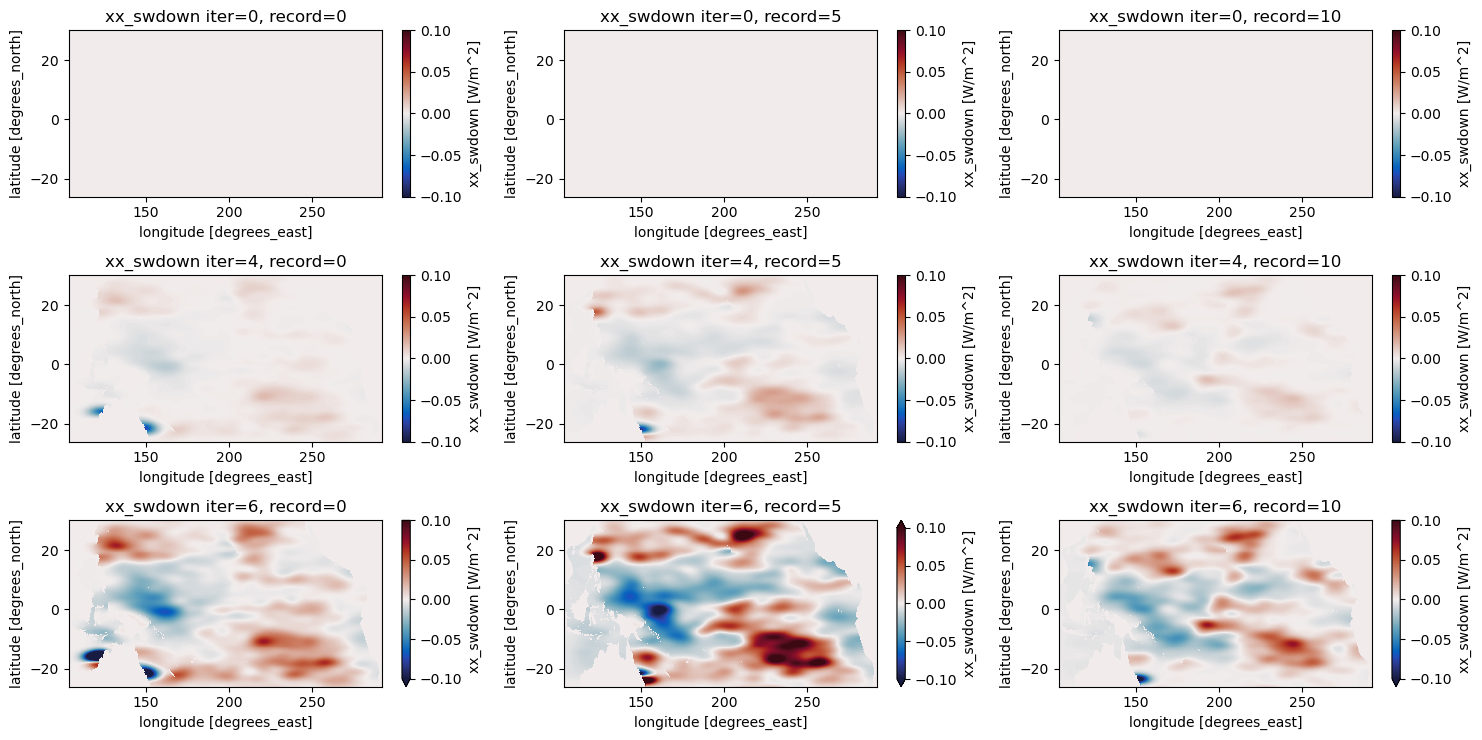

In [22]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_swdown'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance, vmin=-1e-1, vmax=1e-1)
        axes[row,col].set_title(f'xx_swdown iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_swdown.png')

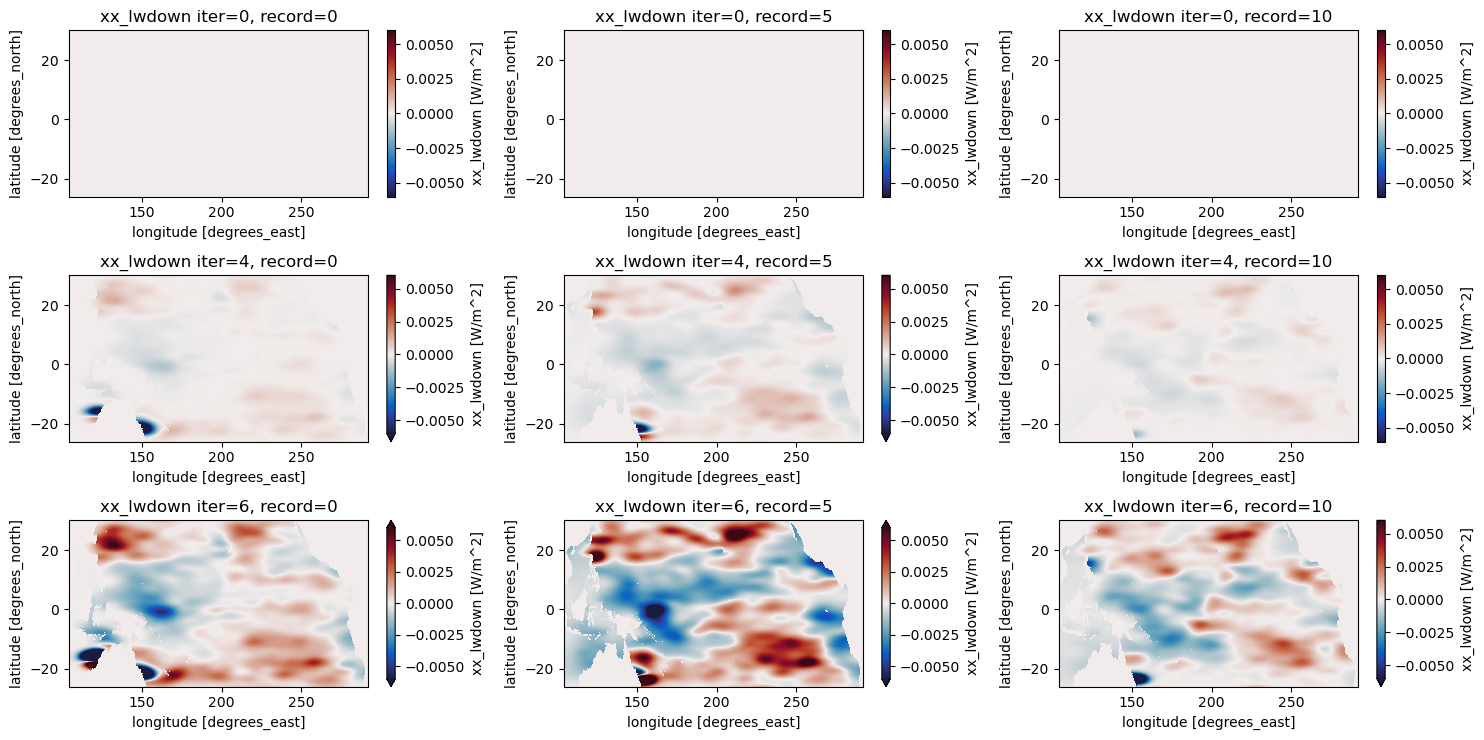

In [23]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_lwdown'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance, vmin=-6e-3, vmax=6e-3)
        axes[row,col].set_title(f'xx_lwdown iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_lwdown.png')

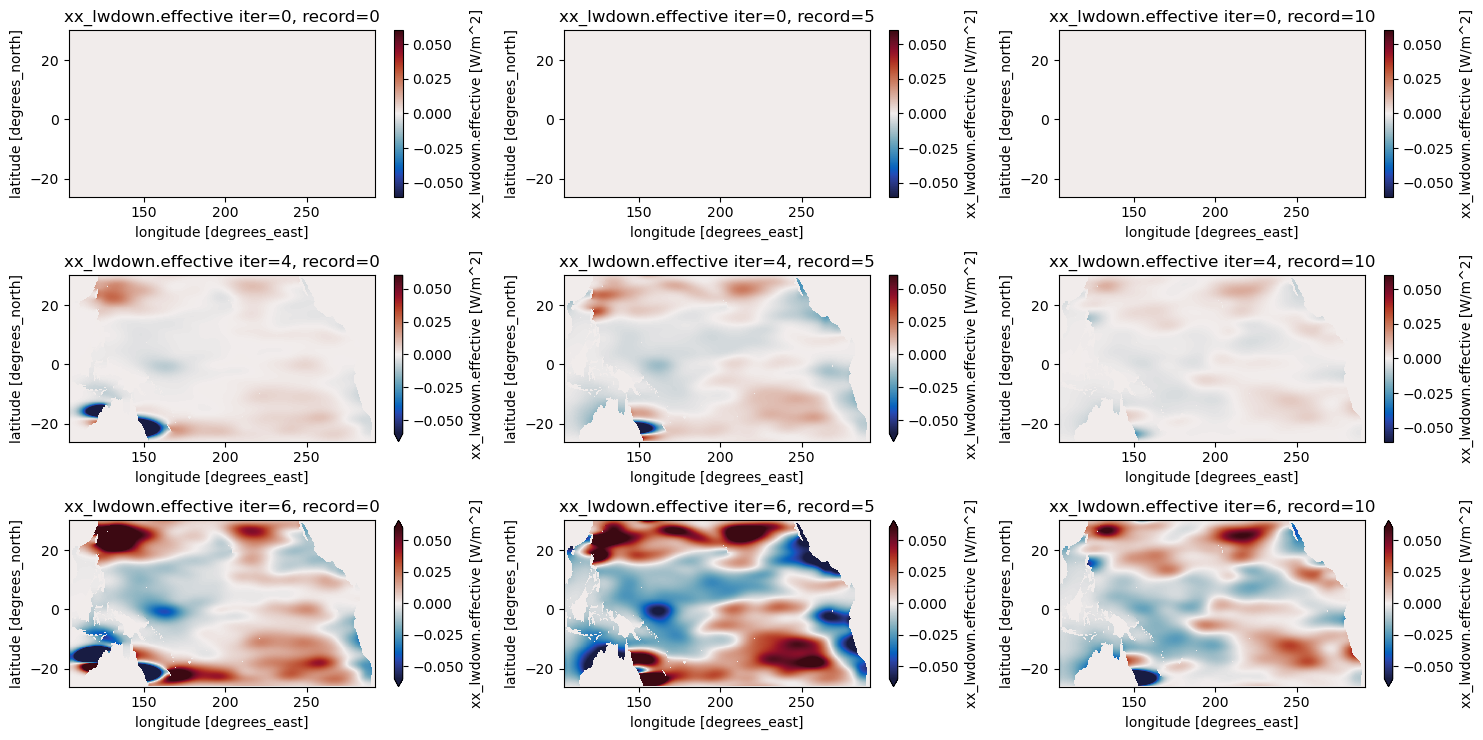

In [24]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_lwdown.effective'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance, vmin=-6e-2, vmax=6e-2)
        axes[row,col].set_title(f'xx_lwdown.effective iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_lwdown_effective.png')

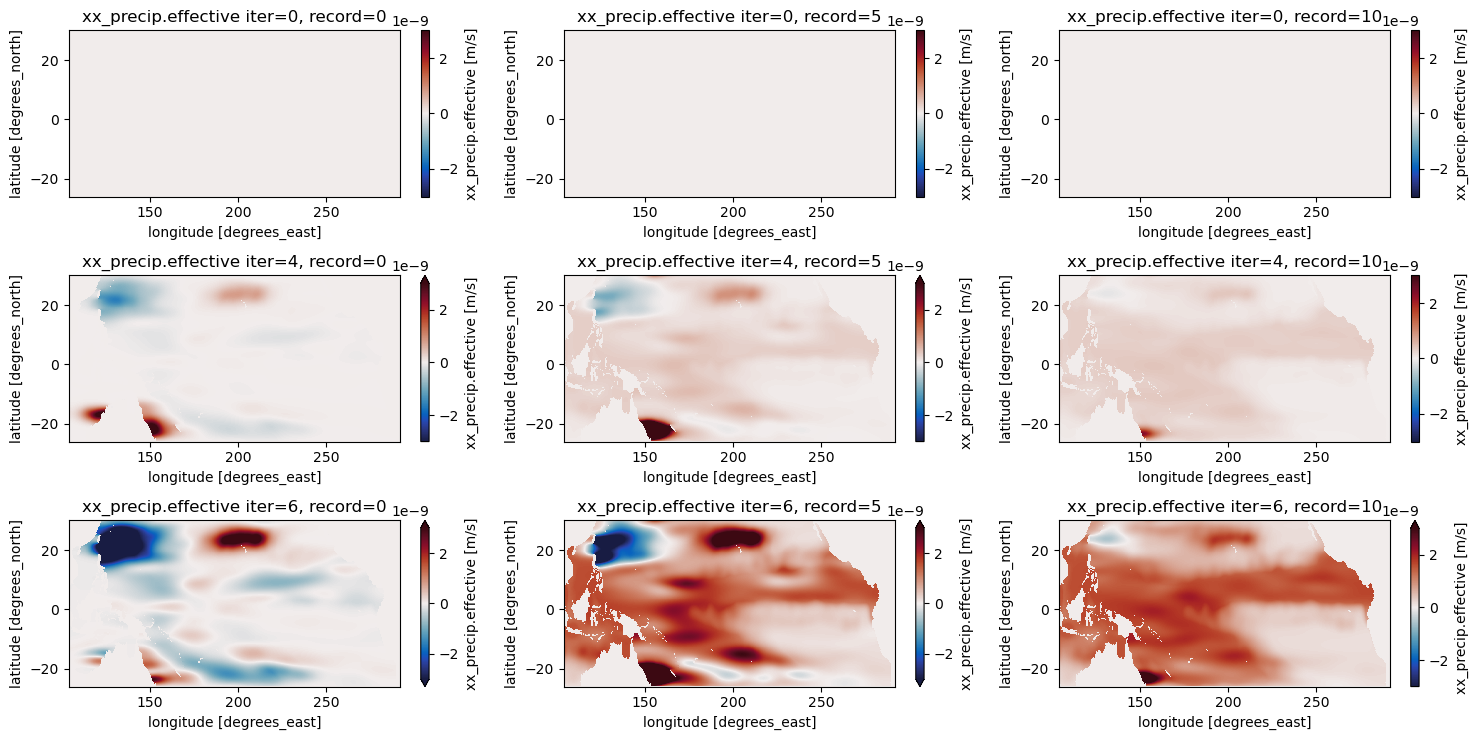

In [25]:

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_precip.effective'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance, vmin=-3e-9, vmax=3e-9)
        axes[row,col].set_title(f'xx_precip.effective iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_precip_effective.png')

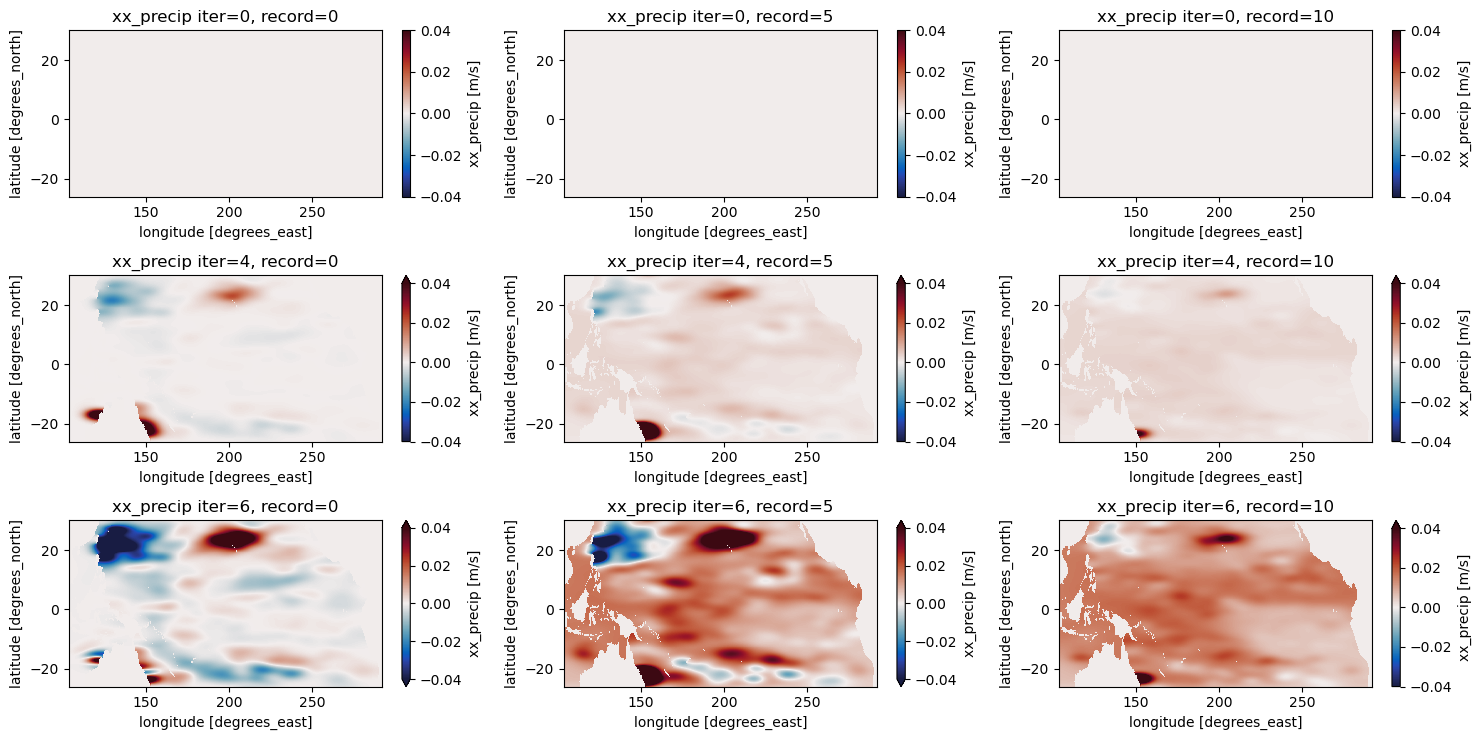

In [26]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_precip'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance, vmin=-4e-2, vmax=4e-2)
        axes[row,col].set_title(f'xx_precip iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_precip.png')

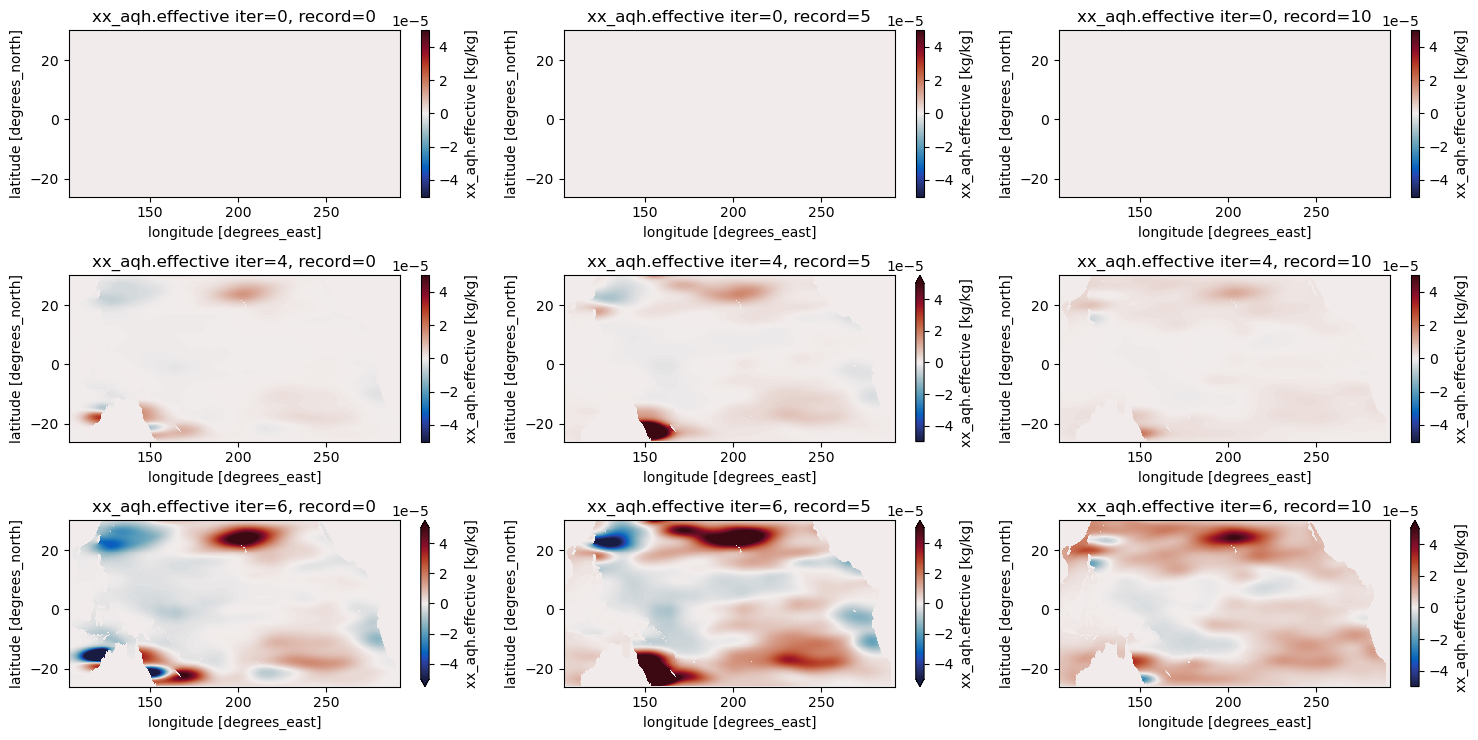

In [27]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_aqh.effective'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance,vmin=-0.5e-4,vmax=0.5e-4)
        axes[row,col].set_title(f'xx_aqh.effective iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_aqh_effective.png')

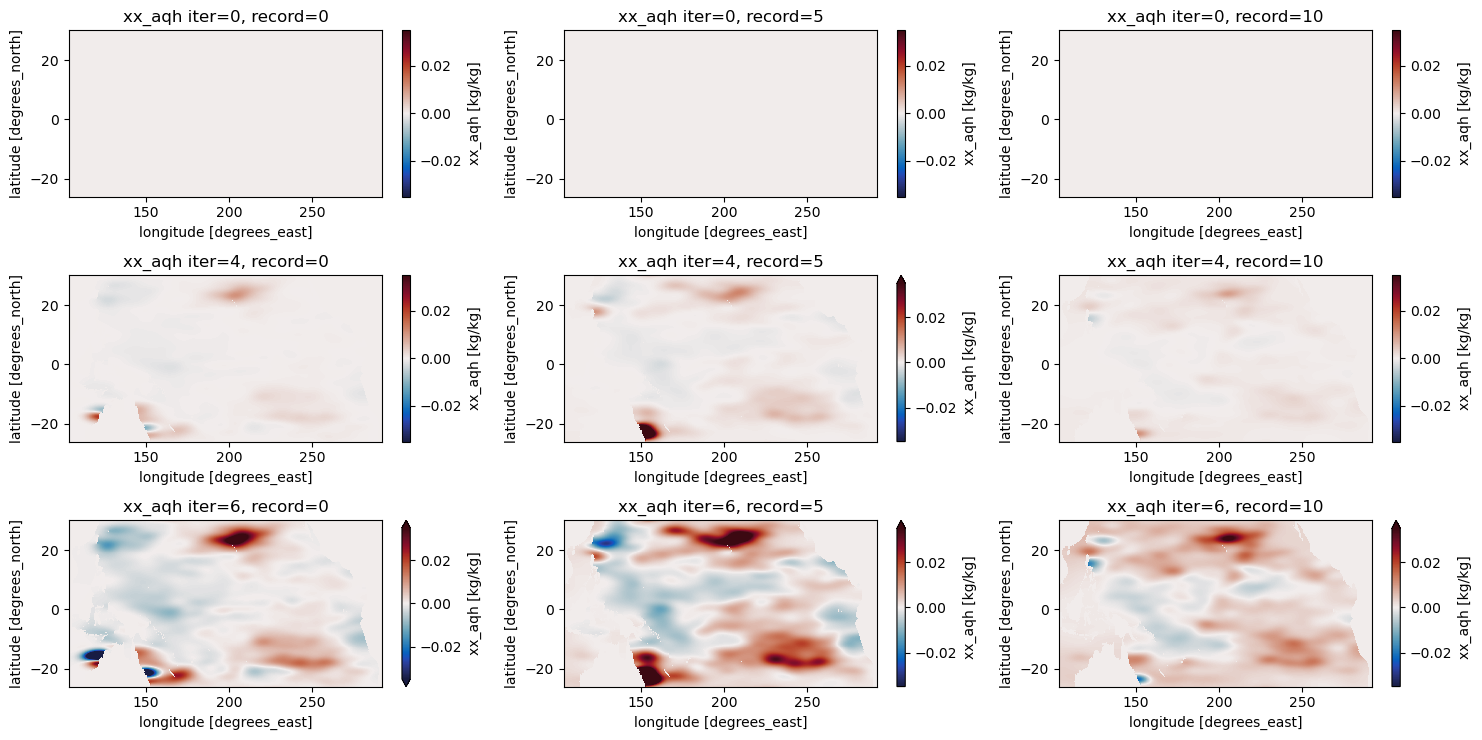

In [28]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['xx_aqh'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance,vmin=-3.5e-2,vmax=3.5e-2)
        axes[row,col].set_title(f'xx_aqh iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/xx_aqh.png')

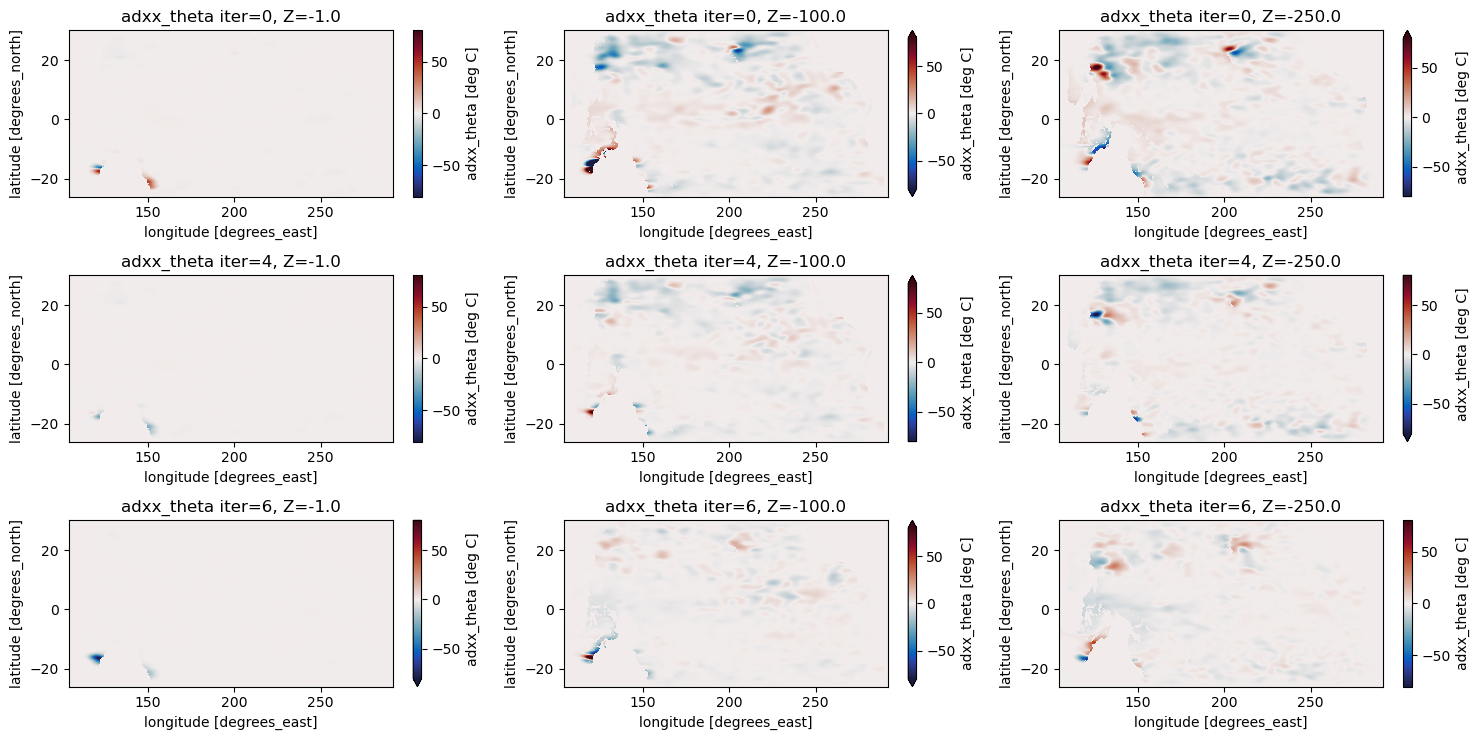

In [29]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['adxx_theta'].isel(iter=iter).sel(Z=[levels[col]],method='nearest').plot(ax=axes[row,col], cmap=cmo.balance, vmin=-80, vmax=80)
        axes[row,col].set_title(f'adxx_theta iter={ds.iter.values[iter]}, Z={levels[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/adxx_theta.png')

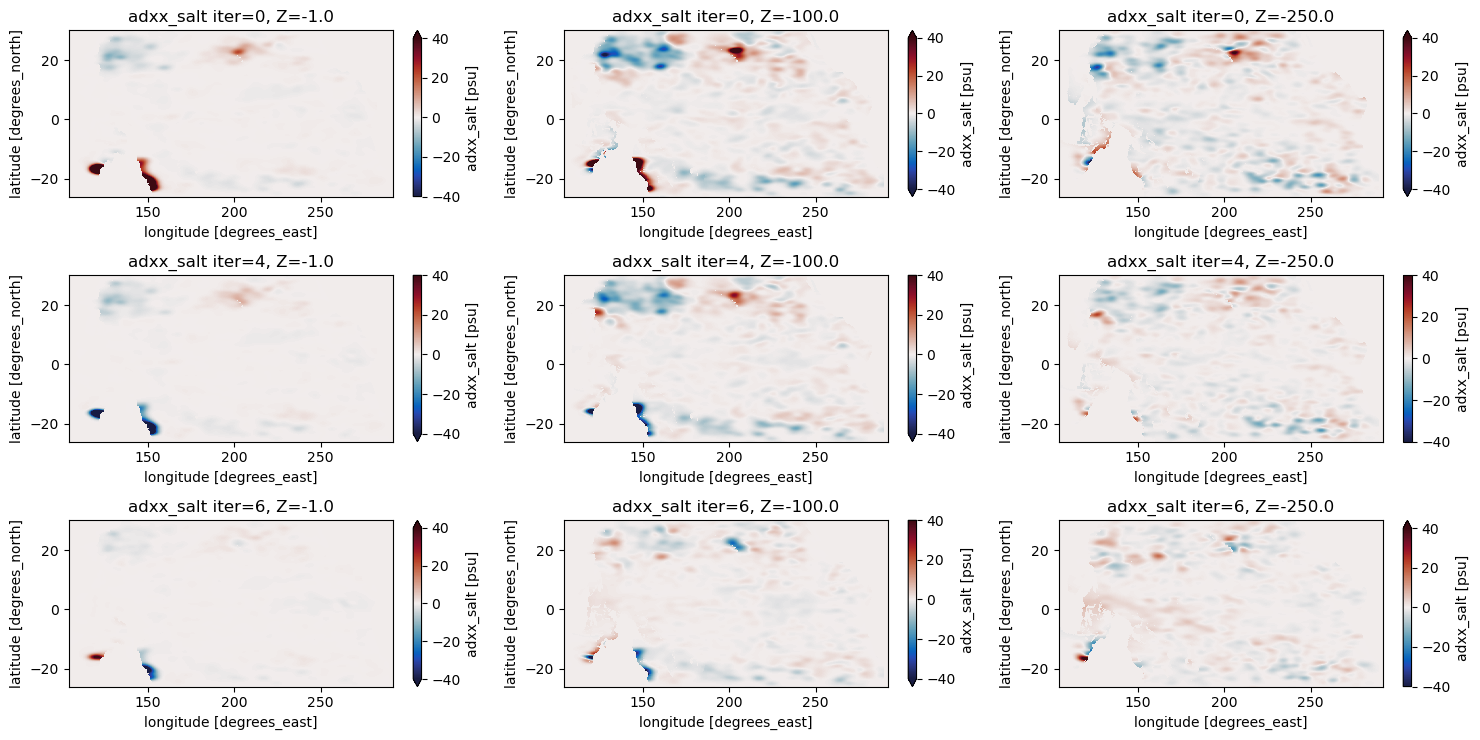

In [30]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['adxx_salt'].isel(iter=iter).sel(Z=[levels[col]],method='nearest').plot(ax=axes[row,col], cmap=cmo.balance, vmin=-40,vmax=40)
        axes[row,col].set_title(f'adxx_salt iter={ds.iter.values[iter]}, Z={levels[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/adxx_salt.png')

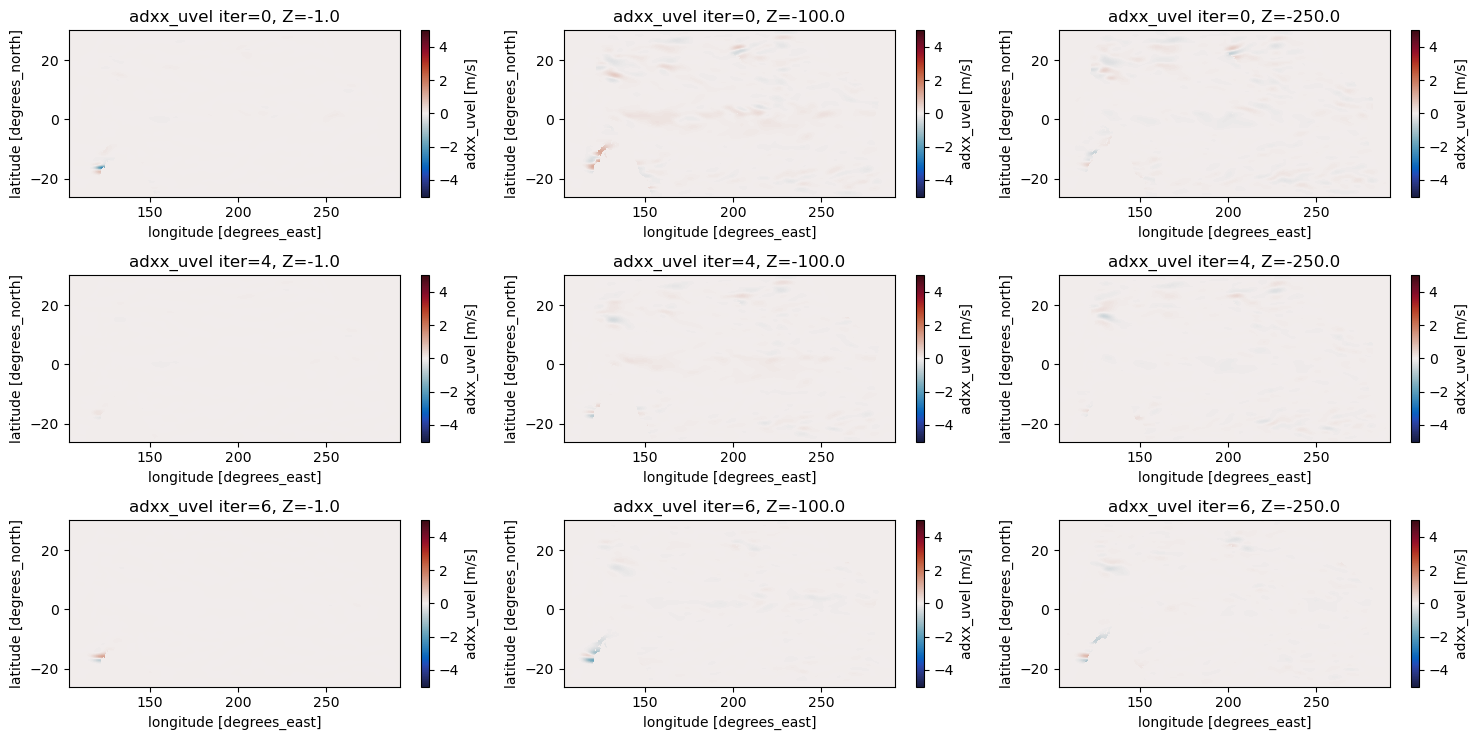

In [31]:

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['adxx_uvel'].isel(iter=iter).sel(Z=[levels[col]],method='nearest').plot(ax=axes[row,col], cmap=cmo.balance, vmin=-5,vmax=5)
        axes[row,col].set_title(f'adxx_uvel iter={ds.iter.values[iter]}, Z={levels[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/adxx_uvel.png')

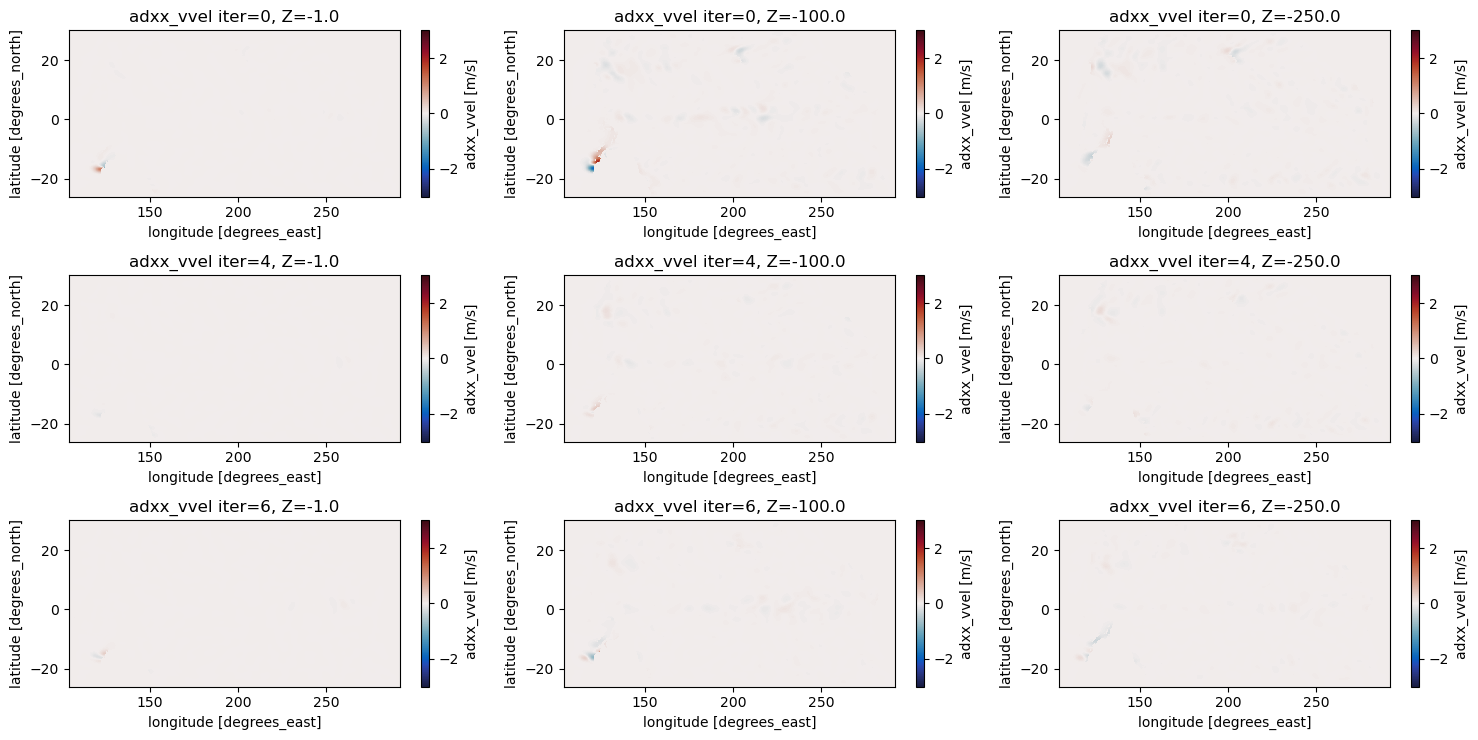

In [32]:

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['adxx_vvel'].isel(iter=iter).sel(Z=[levels[col]],method='nearest').plot(ax=axes[row,col], cmap=cmo.balance, vmin=-3,vmax=3)
        axes[row,col].set_title(f'adxx_vvel iter={ds.iter.values[iter]}, Z={levels[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/adxx_vvel.png')

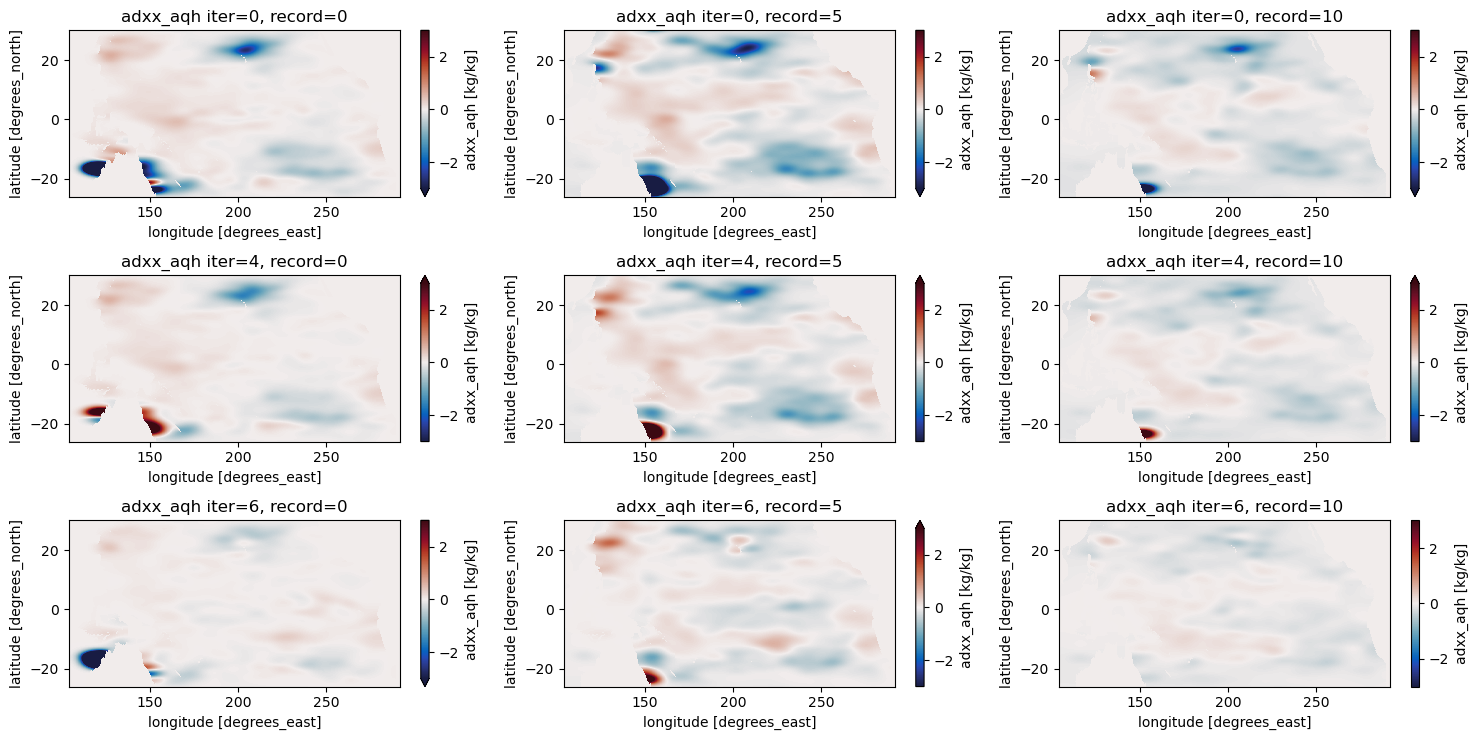

In [33]:

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['adxx_aqh'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance,vmin=-3,vmax=3)
        axes[row,col].set_title(f'adxx_aqh iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/adxx_aqh.png')

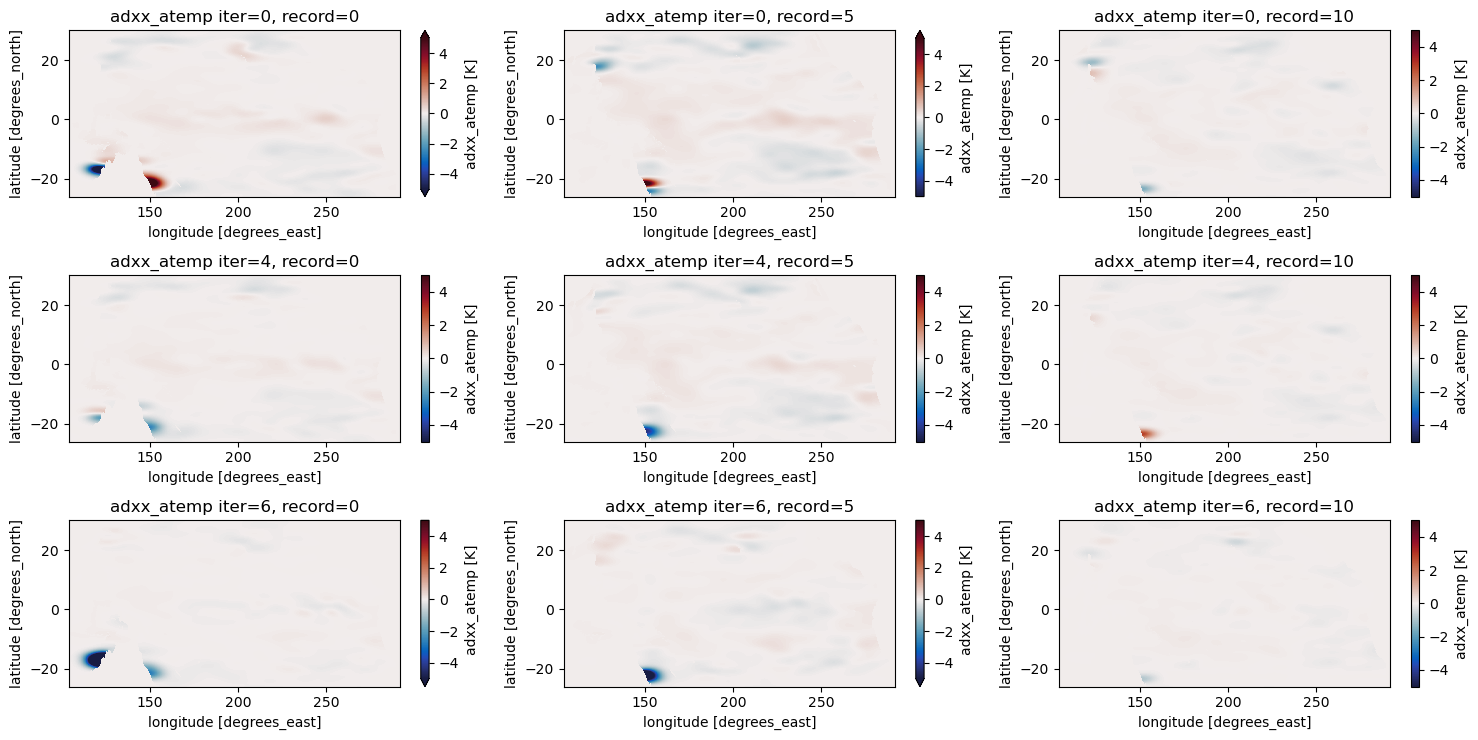

In [34]:

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['adxx_atemp'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance,vmin=-5,vmax=5)
        axes[row,col].set_title(f'adxx_atemp iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/adxx_atemp.png')

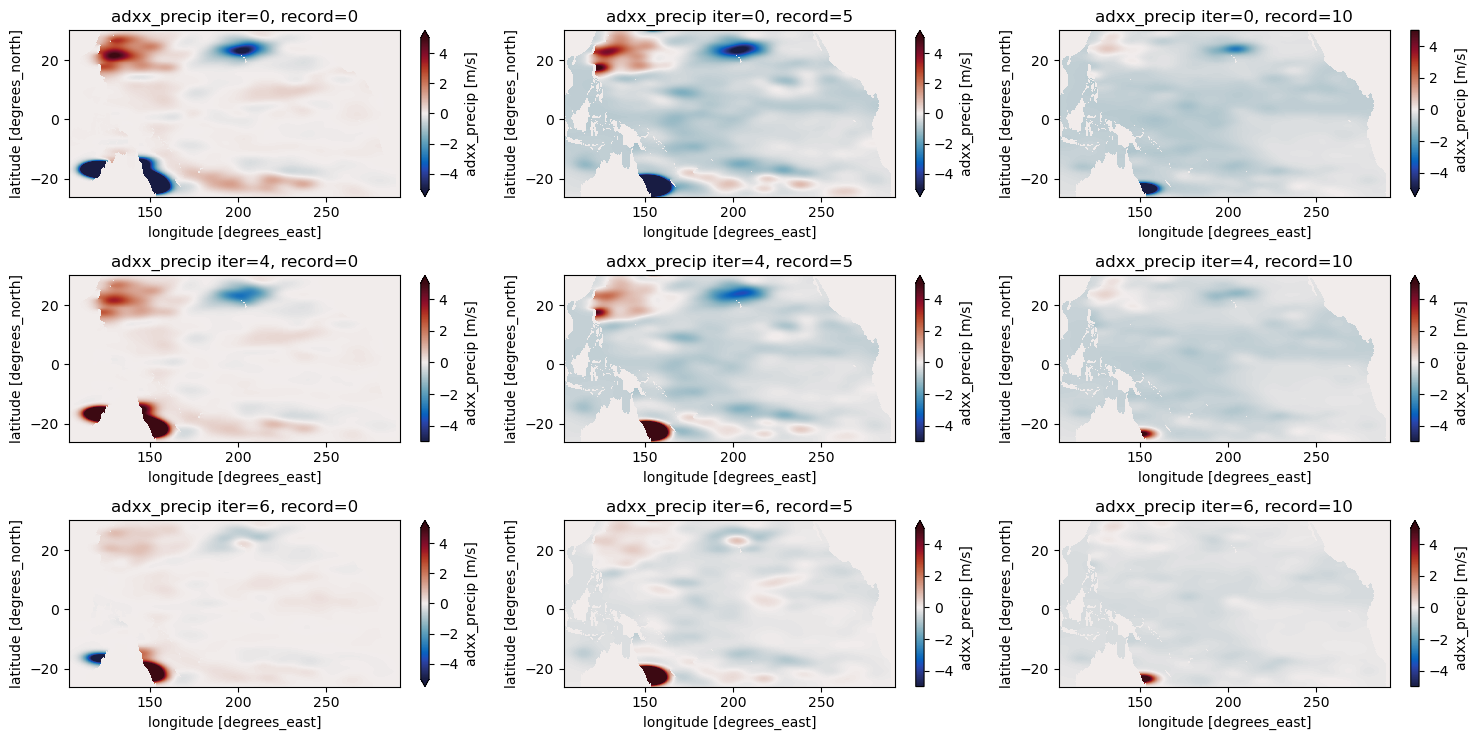

In [35]:

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

# iterate over rows and colunns of axes, such that each row is an iteration and each column is a depth
for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['adxx_precip'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance,vmin=-5,vmax=5)
        axes[row,col].set_title(f'adxx_precip iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/adxx_precip.png')

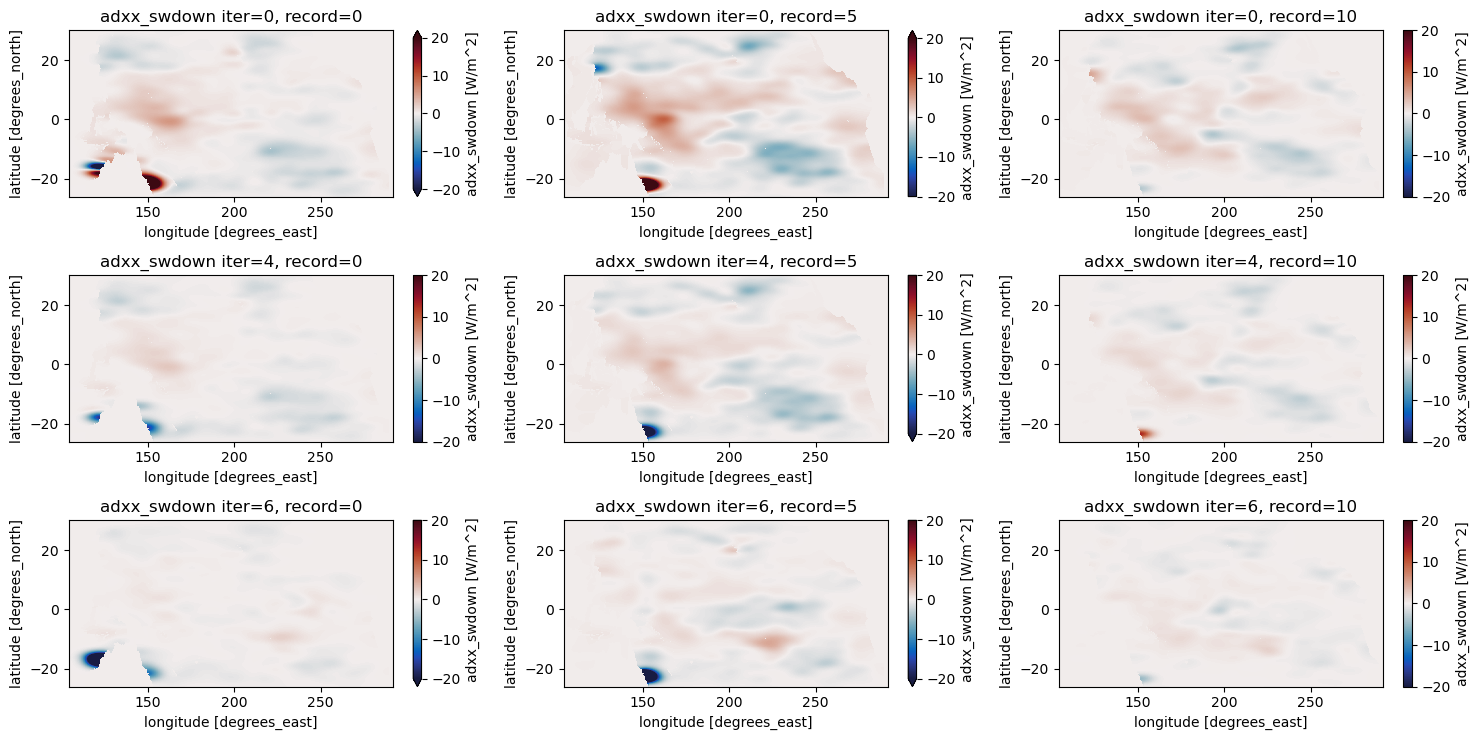

In [36]:

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['adxx_swdown'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance,vmin=-20,vmax=20)
        axes[row,col].set_title(f'adxx_swdown iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/adxx_swdown.png')

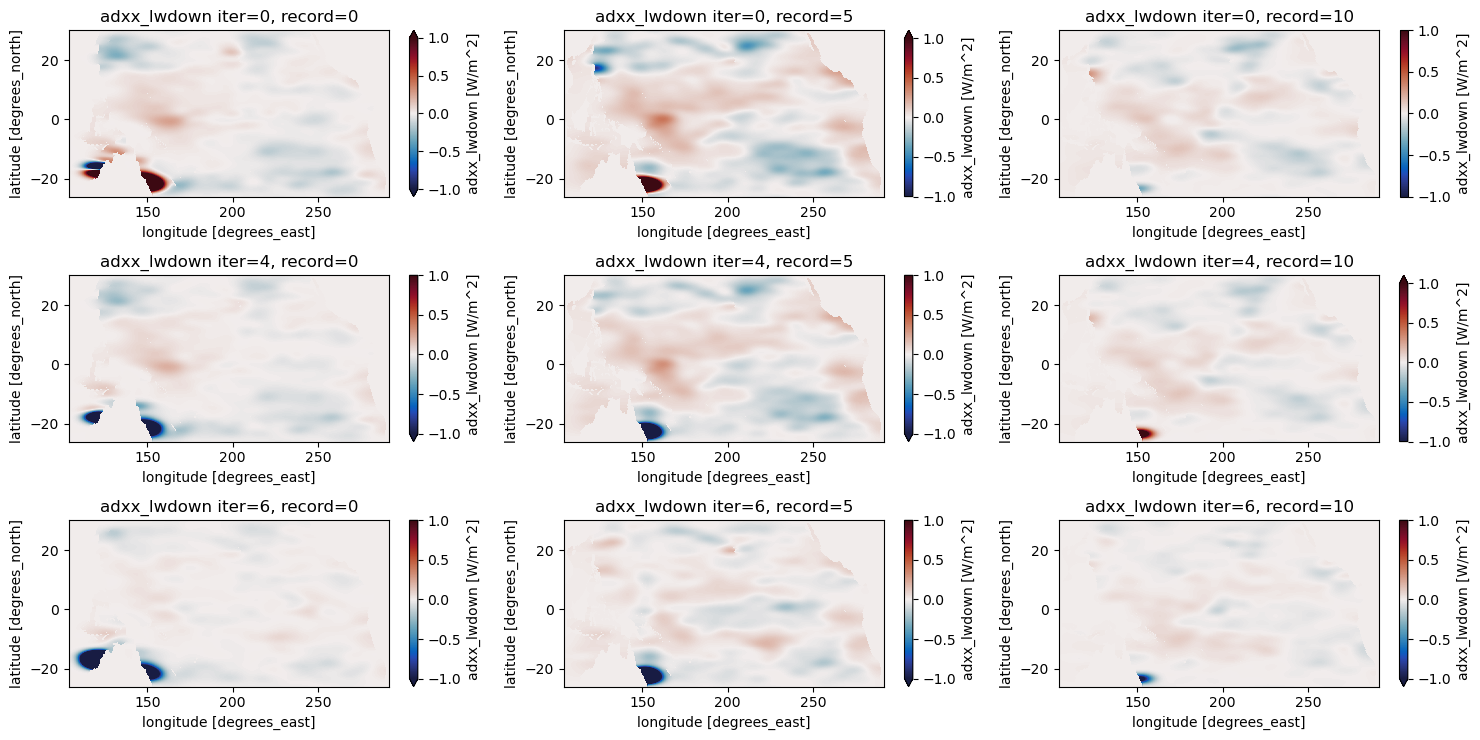

In [37]:

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['adxx_lwdown'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance,vmin=-1,vmax=1)
        axes[row,col].set_title(f'adxx_lwdown iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/adxx_lwdown.png')

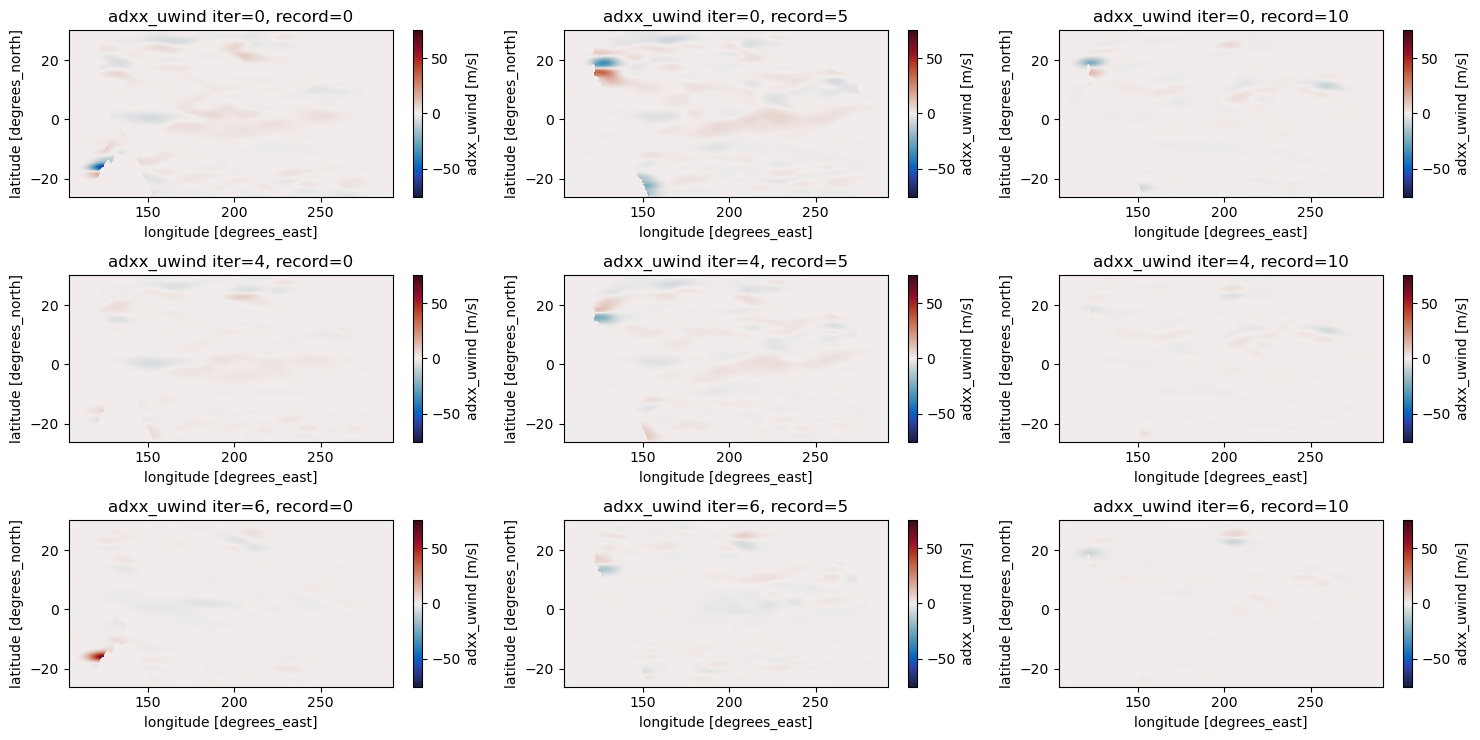

In [38]:

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['adxx_uwind'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance,vmin=-75,vmax=75)
        axes[row,col].set_title(f'adxx_uwind iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/adxx_uwind.png')

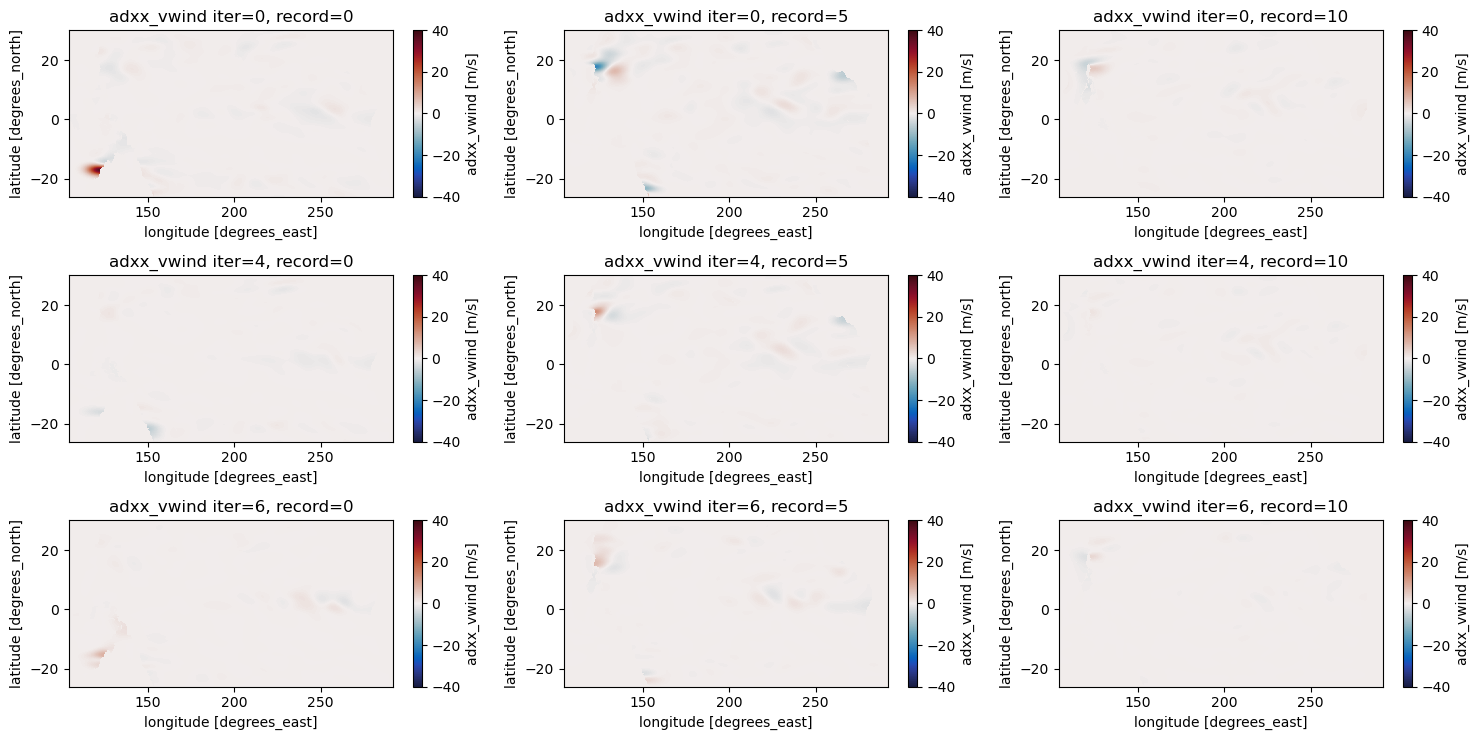

In [39]:

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*2.5))

for row, iter in zip(range(nrows),iters):
    for col in range(ncols):
        ds['adxx_vwind'].isel(iter=iter,time=records[col]).plot(ax=axes[row,col], cmap=cmo.balance,vmin=-40,vmax=40)
        axes[row,col].set_title(f'adxx_vwind iter={ds.iter.values[iter]}, record={records[col]}')

plt.tight_layout()
fig.savefig('/home/edavenport/analysis/TPOSE6_VelocityAssim/velocity_withhold/controls/adxx_vwind.png')

In [40]:
cluster.close()
client.shutdown()

In [41]:
client.close()